# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified versions
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data.
import numpy as np
import pandas as pd

# For splitting the dataset.
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns.
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows.
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers.
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores.
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline.
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize.
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model.
import joblib

# os related functionalities.
import os

# API request.
import requests

# for hugging face space authentication to upload files.
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [3]:
original = pd.read_csv("SuperKart.csv")

In [4]:
# Copying data to another variable to avoid any changes to original data.
df = original.copy()

# **Data Overview**

## View the first and last 5 rows of the dataset

In [5]:
df.head(5) # Displaying the first 5 rows of the dataset.

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [6]:
df.tail(5) # Displaying the last 5 rows of the dataset.

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


## Understand the shape of the dataset

In [7]:
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

There are 8763 rows and 12 columns.


## Check the data types of the columns for the dataset

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   str    
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   str    
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   str    
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   str    
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   str    
 9   Store_Location_City_Type   8763 non-null   str    
 10  Store_Type                 8763 non-null   str    
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 821.7 KB


* No missing values are shown, and there are 5 numeric and 7 object (string) variables.

In [9]:
# Print the unique values and its value counts of object features.
for column in df.columns:
    if df[column].dtype == "str":
      display(df[column].value_counts())

Product_Id
FD6114    1
FD7839    1
FD5075    1
FD8233    1
NC1180    1
         ..
NC7546    1
NC584     1
NC2471    1
NC7187    1
FD306     1
Name: count, Length: 8763, dtype: int64

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64

Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64

Store_Id
OUT004    4676
OUT001    1586
OUT003    1349
OUT002    1152
Name: count, dtype: int64

Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64

Store_Location_City_Type
Tier 2    6262
Tier 1    1349
Tier 3    1152
Name: count, dtype: int64

Store_Type
Supermarket Type2     4676
Supermarket Type1     1586
Departmental Store    1349
Food Mart             1152
Name: count, dtype: int64

* In Product Sugar Content there are 4 values, but "reg" and "Regular" refer to the same category, so this will be addressed.

In [10]:
df["Product_Sugar_Content"]=df["Product_Sugar_Content"].replace('reg', 'Regular', inplace=True)

In [11]:
df["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

In [12]:
# Convert string data type column into category type to reduce memory space.
for column in df.columns:
    if df[column].dtype == "str":
      df[column] = pd.Categorical(df[column])
    

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Product_Id                 8763 non-null   category
 1   Product_Weight             8763 non-null   float64 
 2   Product_Sugar_Content      8763 non-null   category
 3   Product_Allocated_Area     8763 non-null   float64 
 4   Product_Type               8763 non-null   category
 5   Product_MRP                8763 non-null   float64 
 6   Store_Id                   8763 non-null   category
 7   Store_Establishment_Year   8763 non-null   int64   
 8   Store_Size                 8763 non-null   category
 9   Store_Location_City_Type   8763 non-null   category
 10  Store_Type                 8763 non-null   category
 11  Product_Store_Sales_Total  8763 non-null   float64 
dtypes: category(7), float64(4), int64(1)
memory usage: 479.6 KB


## Statistical summary of the data

**Let's check the statistical summary of the data.**

In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,DR1005,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,3,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Checking for duplicate values

In [15]:
# Checking for duplicate values.
df.duplicated().sum()

np.int64(0)

* There are no duplicates.

## Checking for missing values

In [16]:
# Checking for missing values in the data.
df.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

* There are no missing values.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [17]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### **Product_Weight**

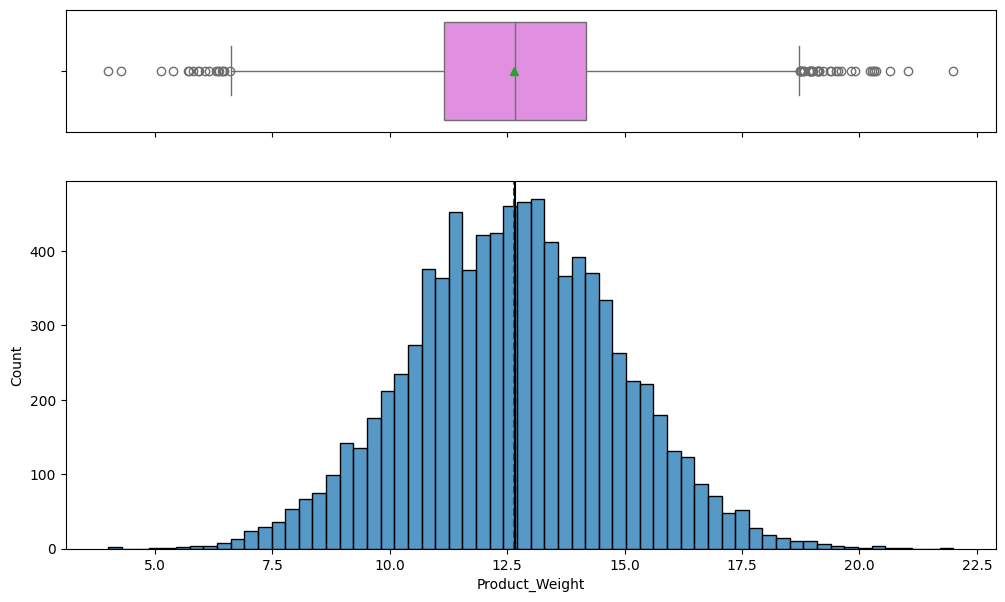

In [18]:
histogram_boxplot(df, "Product_Weight")

* Simetrical distribution with mean and median around 12.6.
* There are outliers visible in the box plot, in both whiskers.

### **Product_Allocated_Area**

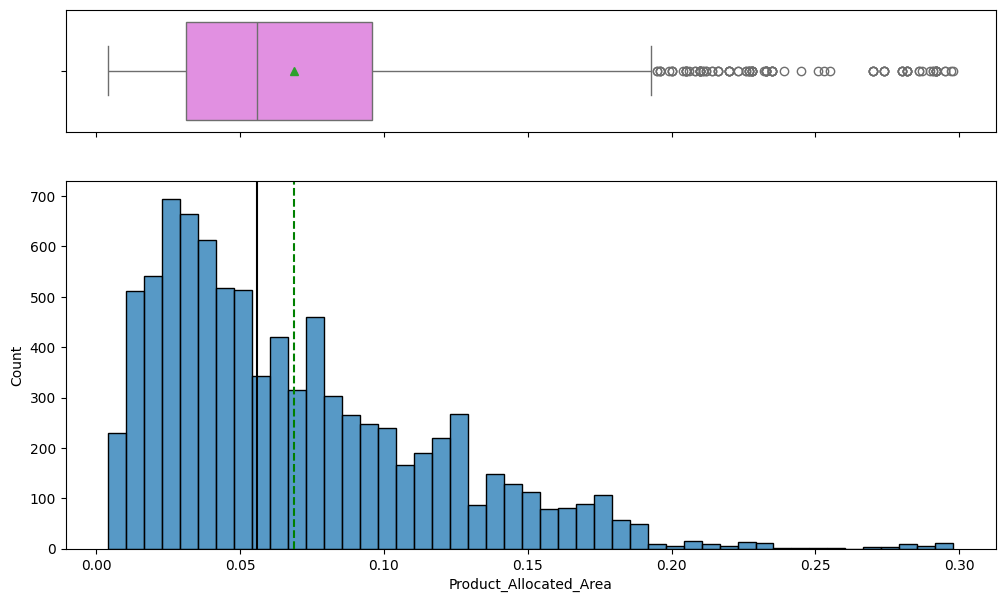

In [19]:
histogram_boxplot(df, "Product_Allocated_Area") 

* Right skewed distribution with mean (0.068) higher than median (0.056).
* There are outliers visible in the box plot, in the upper whisker.

### **Product_MRP**

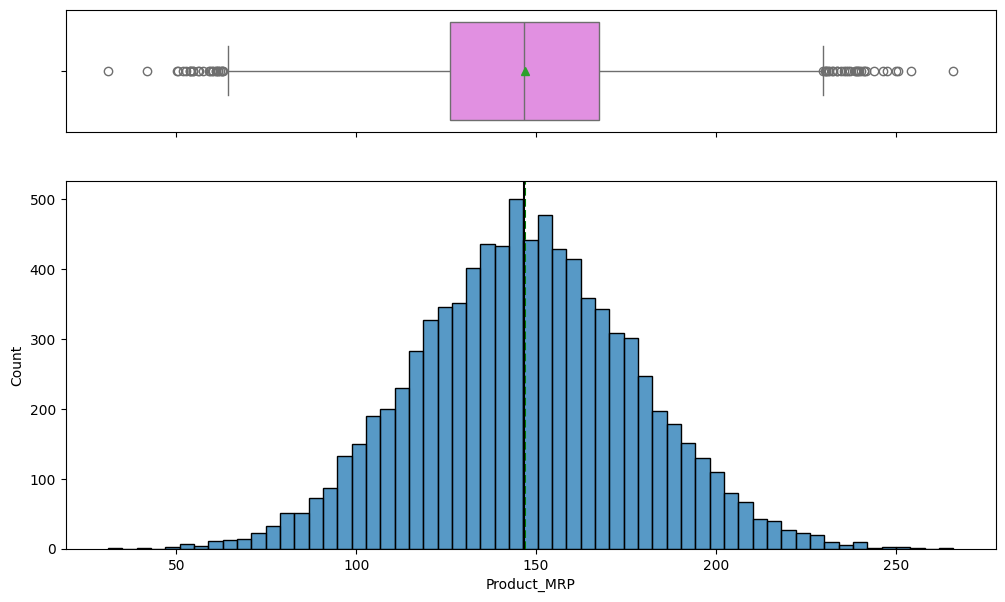

In [20]:
histogram_boxplot(df, "Product_MRP")

* Simetrical distribution with mean and median around 147.
* There are outliers visible in the box plot, in both whiskers.

### **Product_Store_Sales_Total**

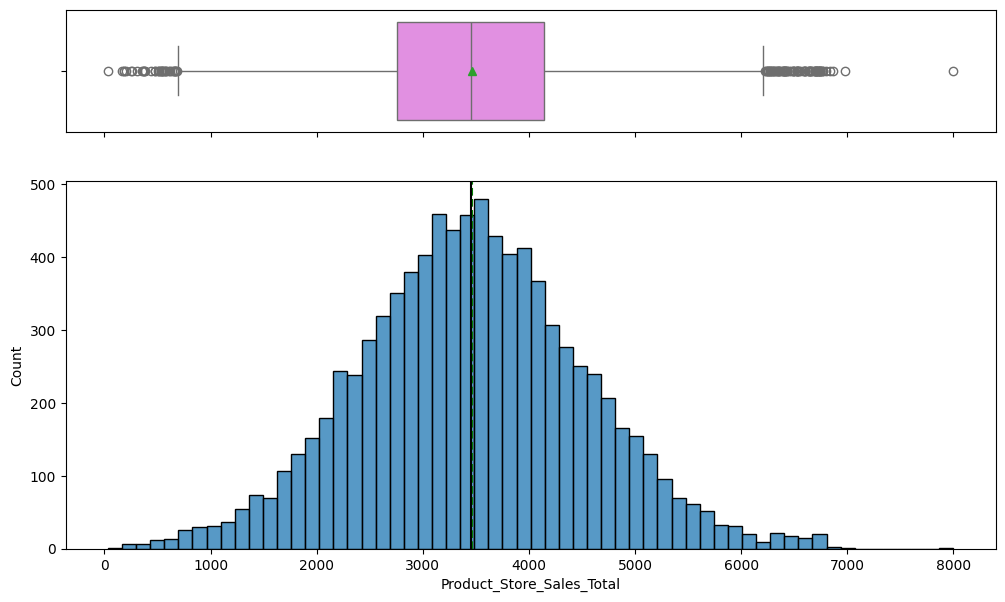

In [21]:
histogram_boxplot(df, "Product_Store_Sales_Total") 

* Simetrical distribution with mean and median around 3460.
* There are outliers visible in the box plot, in both whiskers.

In [22]:
# function to create labeled barplots.


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### **Product_Sugar_Content**

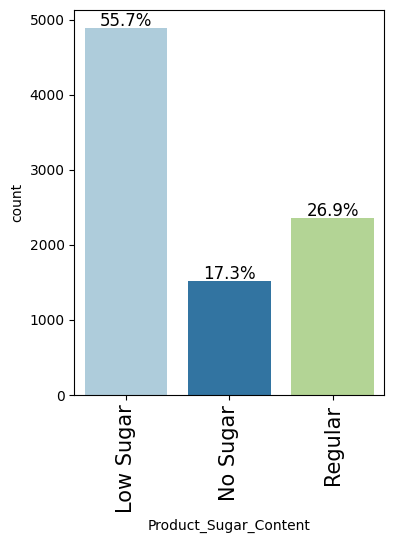

In [23]:
labeled_barplot(df, "Product_Sugar_Content", perc=True)

* Low Sugar products are most common with 55.7%.

### **Product_Type**

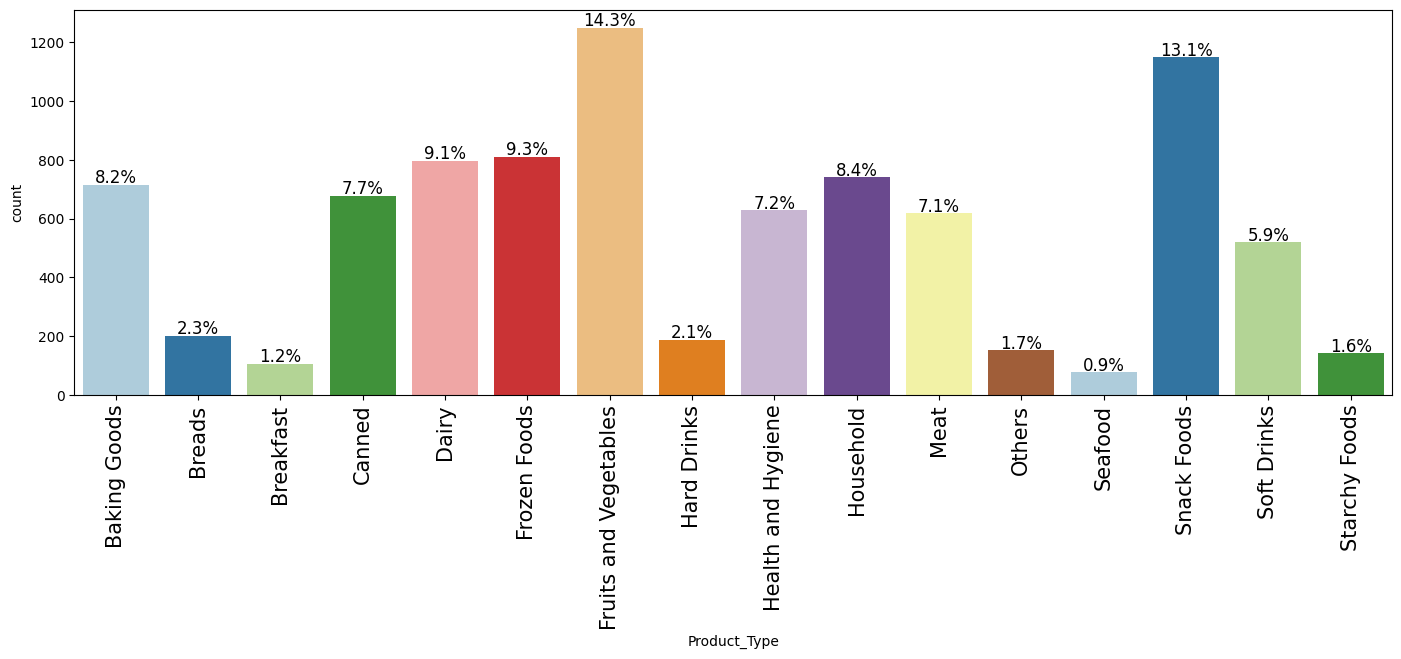

In [24]:
labeled_barplot(df, "Product_Type", perc=True) 

* Fruits and Vegetables (14.3%) & Snack Foods (13.1%) are most common, followed by Frozen Foods (9.3) and Dairy (9.1).

### **Store_Id**

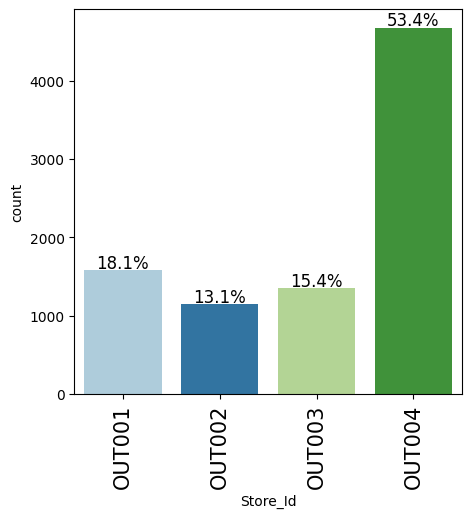

In [25]:
labeled_barplot(df, "Store_Id", perc=True) 

* Store ID OUT004 is the most common with 53.4%.

### **Store_Size**

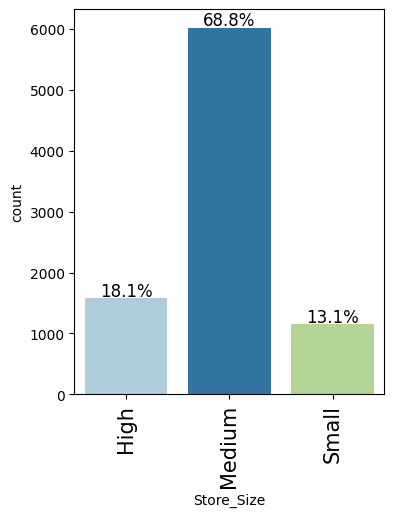

In [26]:
labeled_barplot(df, "Store_Size", perc=True) 

* Medium is the most frequent size with 68.8%.

### **Store_Location_City_Type**

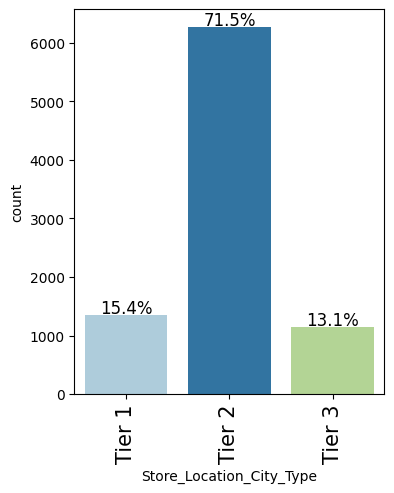

In [27]:
labeled_barplot(df, "Store_Location_City_Type", perc=True) 

* Tier 2 is the most frequent type with 71.5%.

### **Store_Type**

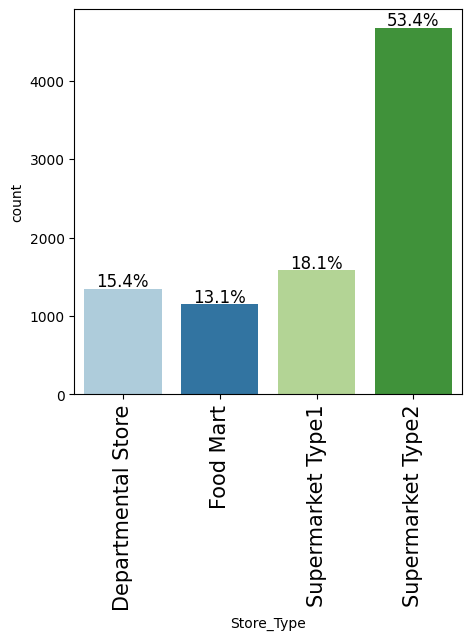

In [28]:
labeled_barplot(df, "Store_Type", perc=True) 

* Supermarket Type2 is the most frequent store type with 53.4%.

## Bivariate Analysis

### **Correlation matrix**

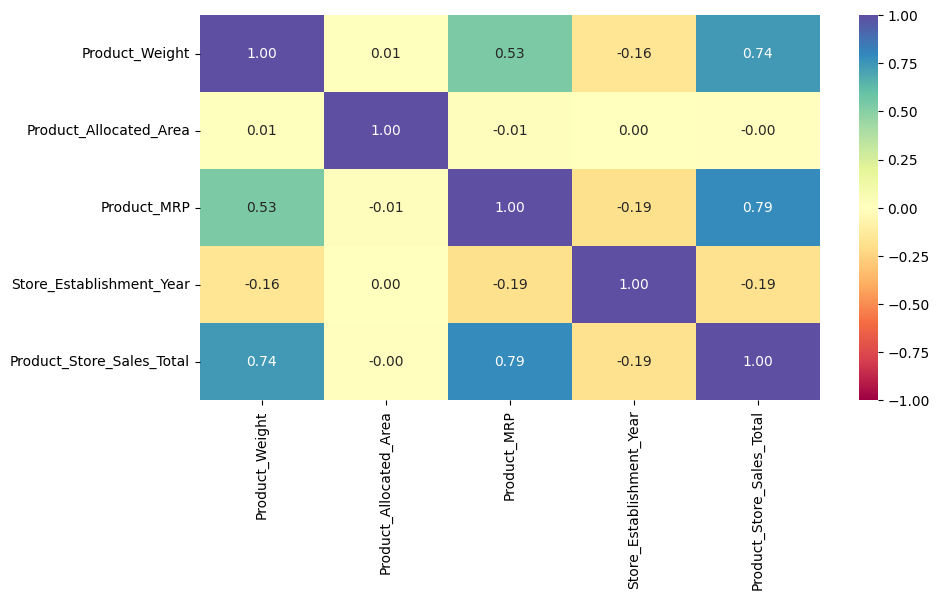

In [29]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

* Both Product Weight and Product MRP show a good positive correlation with target variable Product Store Sales.

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns**

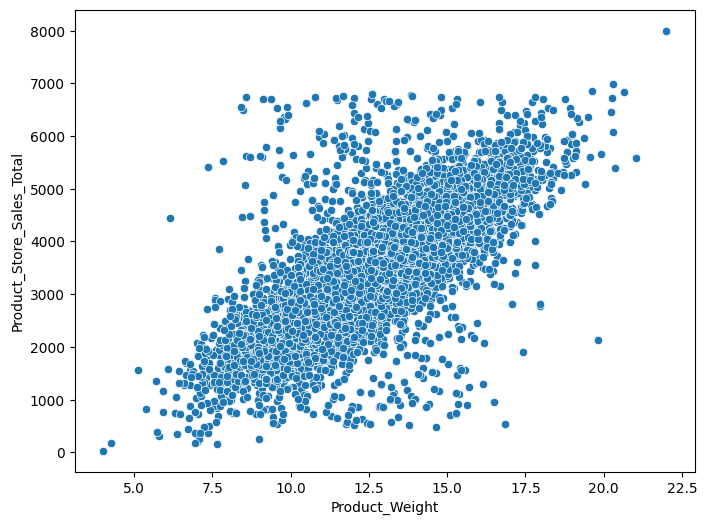

In [30]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=df.Product_Weight, y=df.Product_Store_Sales_Total) # Scatterplot of Product_Weight and Product_Store_Sales_Total.
plt.show()

* As expected, Product Weight has a positive, almost linear, correlation with Product Store Sales.

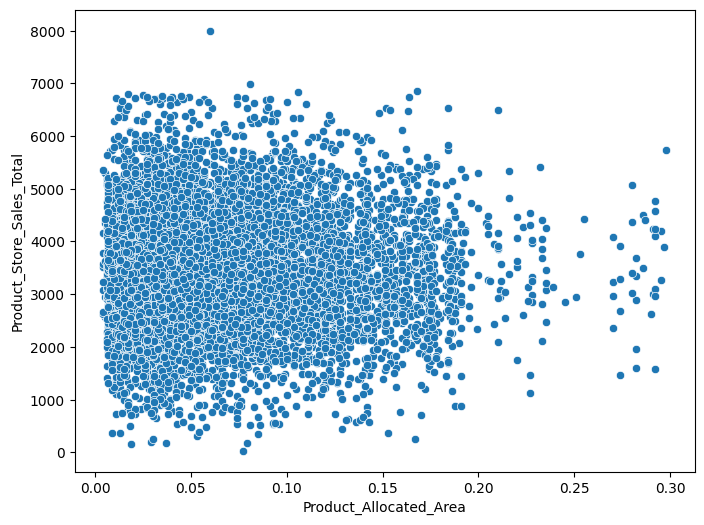

In [31]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=df.Product_Allocated_Area, y=df.Product_Store_Sales_Total) # Scatterplot of Product_Allocated_Area and Product_Store_Sales_Total.
plt.show()

* Product Allocated Area shows no clear correlation with Product Store Sales.

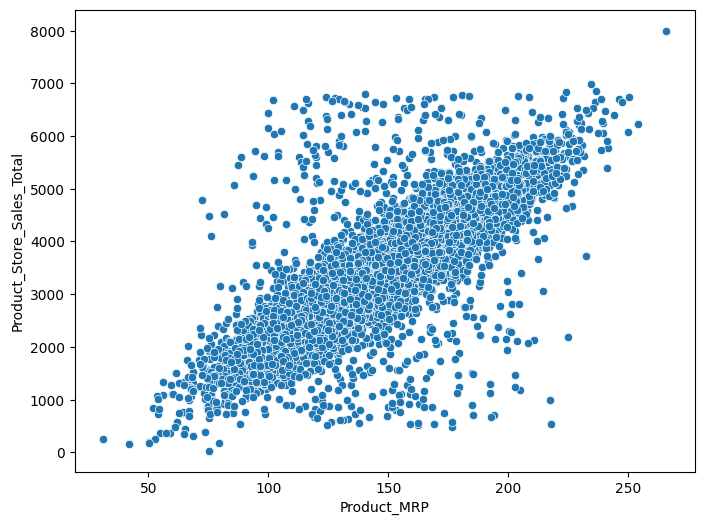

In [32]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=df.Product_MRP, y=df.Product_Store_Sales_Total) # Scatterplot of Product_MRP and Product_Store_Sales_Total.
plt.show()

* Also expected, Product MRP has a positive, almost linear, correlation with Product Store Sales.

### **Let us see from which product type the company is generating most of the revenue**

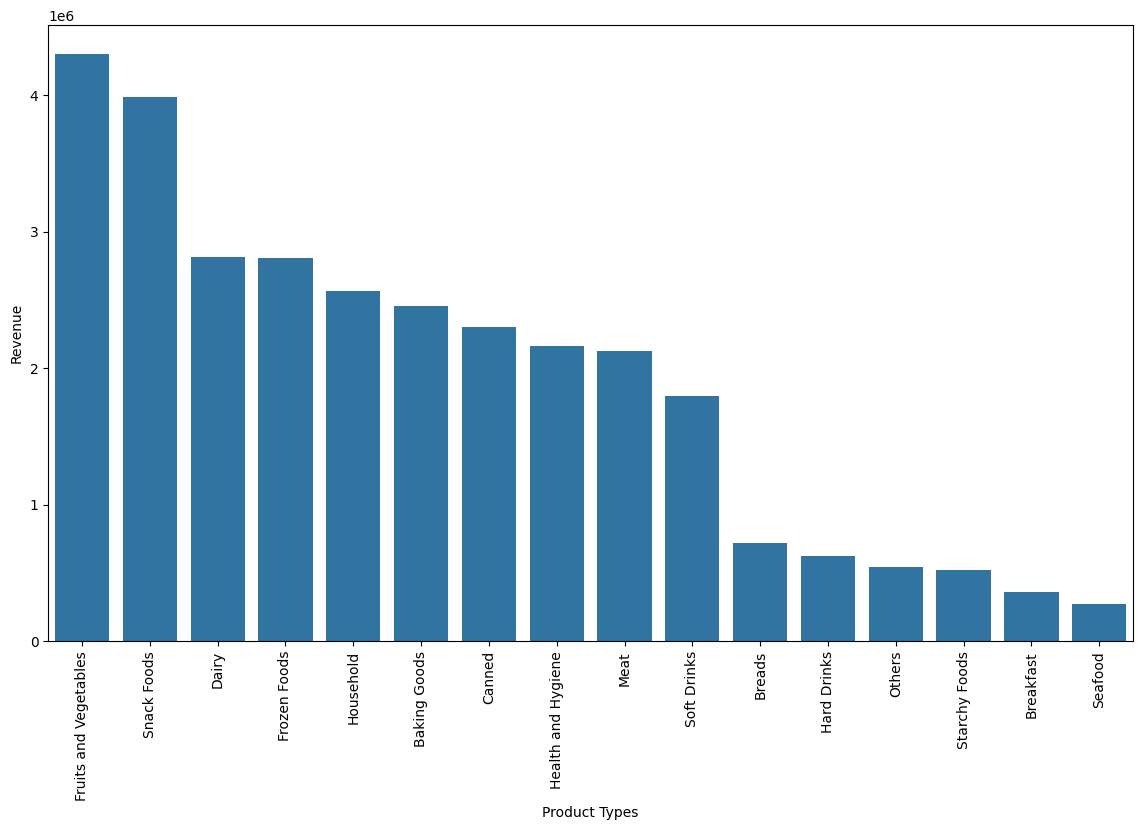

In [33]:
df_revenue1 = df.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum().sort_values(by="Product_Store_Sales_Total", ascending=False)  # Performing a groupby on Product_Type and selecting Product_Store_Sales_Total.

plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total, order=df_revenue1.Product_Type)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

* Fruits and Vegetables & Snack Foods are generating the most revenue, Seafood the least.

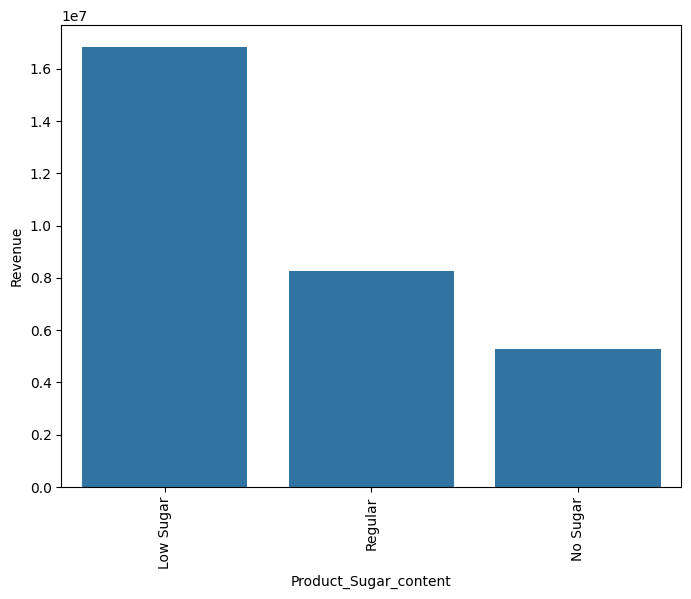

In [34]:
df_revenue2 = df.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"
].sum().sort_values(by="Product_Store_Sales_Total", ascending=False)  # Performing a groupby on Product_Sugar_Content and selecting Product_Store_Sales_Total.
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total, order=df_revenue2.Product_Sugar_Content
)
b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")
plt.show()

* Products Low in Sugar are generating the most revenue, No Sugar the least.

### **Let us see from which type of stores and locations the revenue generation is more**.

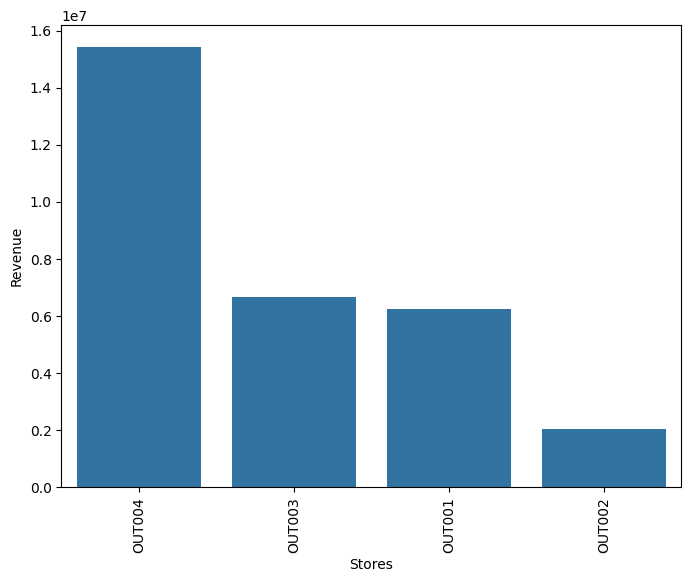

In [35]:
df_store_revenue = df.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum().sort_values(by="Product_Store_Sales_Total", ascending=False) # Performing a groupby on Store_Id and selecting Product_Store_Sales_Total.
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total, order=df_store_revenue.Store_Id
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

* Store ID OUT004 is generating the most revenue, OUT002 the least.

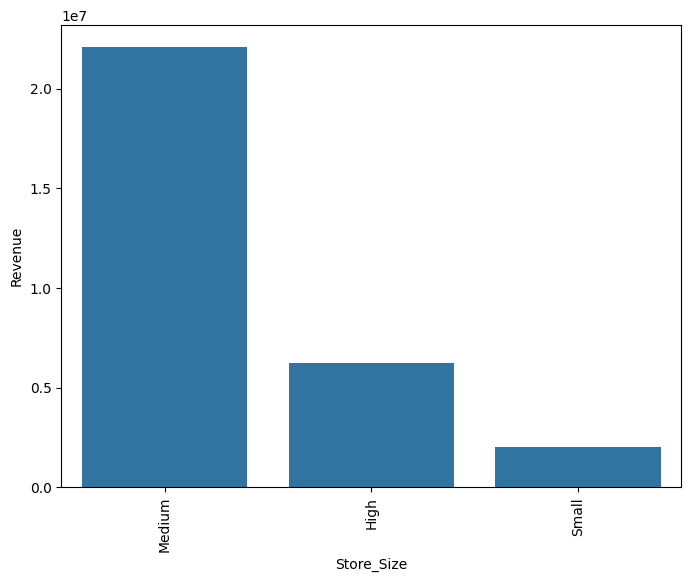

In [36]:
df_revenue3 = df.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum().sort_values(by="Product_Store_Sales_Total", ascending=False) # Performing a groupby on Store_Size and selecting Product_Store_Sales_Total.
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total, order=df_revenue3.Store_Size)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

* Medium Stores are generating the most revenue, Small the least.

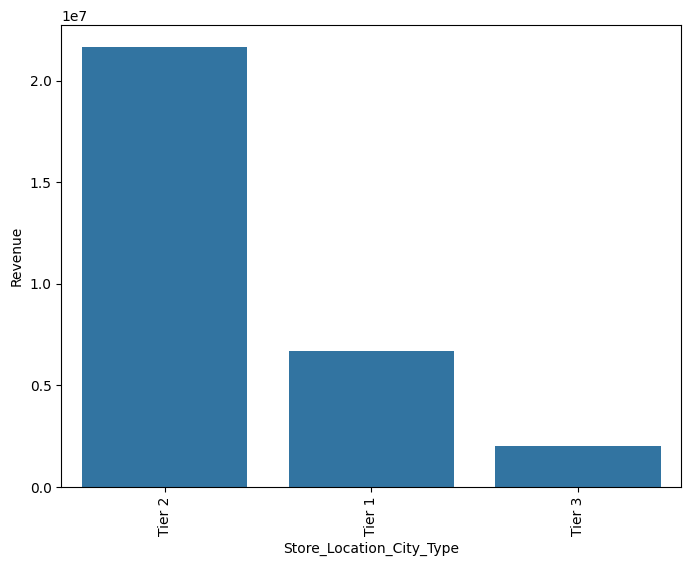

In [37]:
df_revenue4 = df.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum().sort_values(by="Product_Store_Sales_Total", ascending=False) # Performing a groupby on Store_Location_City_Type and selecting Product_Store_Sales_Total.
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total, order = df_revenue4.Store_Location_City_Type
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

* Tier 2 is generating the most revenue, Tier 3 the least.

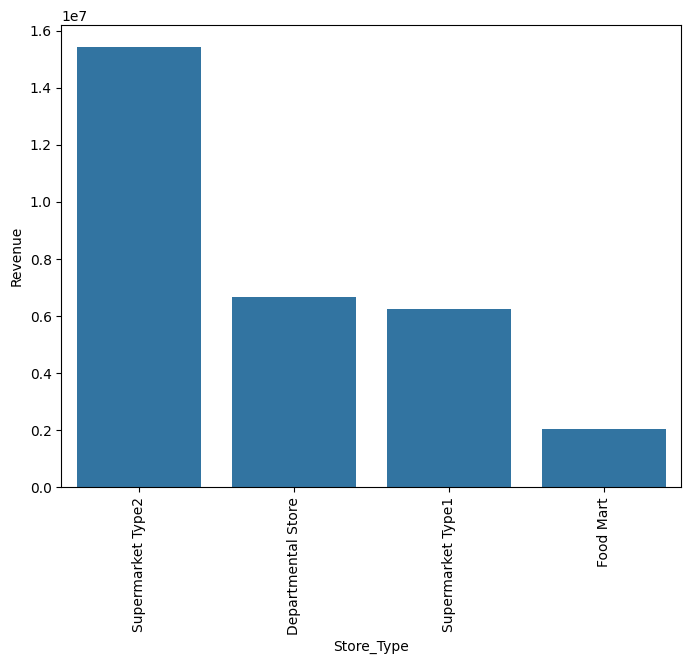

In [38]:
df_revenue5 = df.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum().sort_values(by="Product_Store_Sales_Total", ascending=False) # Performing a groupby on Store_Type and selecting Product_Store_Sales_Total.
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total, order=df_revenue5.Store_Type)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

* Supermarket Type2 is generating the most revenue, Food Mart the least.

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the other categorical columns**

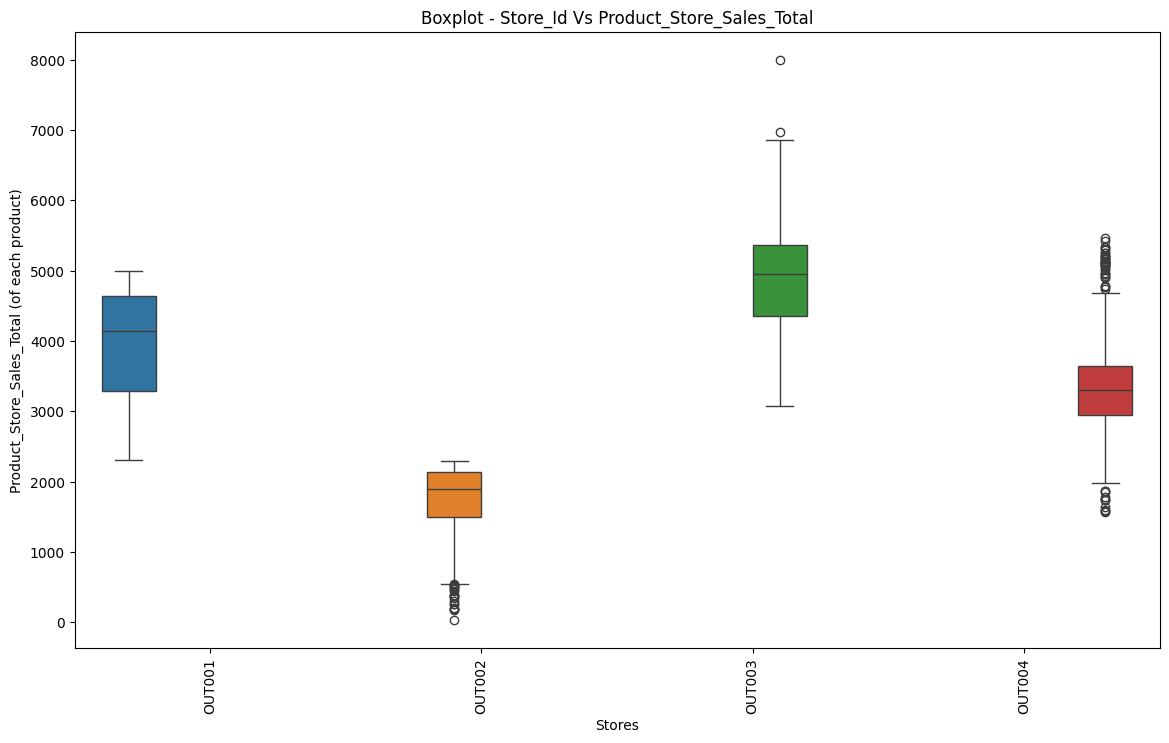

In [39]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=df, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id") # Boxplot with x as Store_Id, y as Product_Store_Sales_Total and hue as Store_Id.
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

* Store OUT003 exhibits the highest median sales **per product**, along with the widest range, including some of the highest individual sales (outliers).
* Store OUT001 shows a good range of sales, with a median higher than OUT002 and OUT004.
* Store OUT004 has a more concentrated distribution of sales, with a median lower than OUT001 and OUT003, although as seen, it outperforms all stores in total sales.
* Store OUT002 consistently displays the lowest median sales and the narrowest sales range, indicating generally lower sales performance per product.

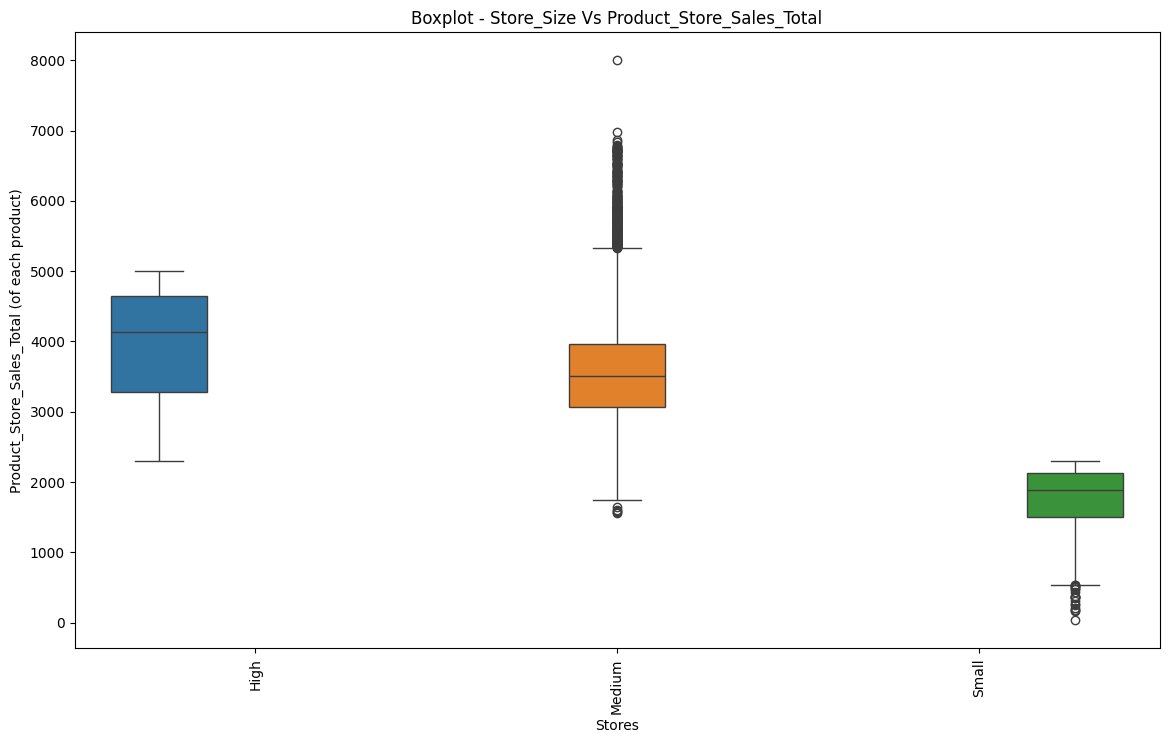

In [40]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = df, x = "Store_Size", y = "Product_Store_Sales_Total", hue = "Store_Size") # Boxplot with x as Store_Size, y as Product_Store_Sales_Total and hue as Store_Size.
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

*   High-sized stores display a highest median sales per product and a wider interquartile range.
*   Medium-sized stores generate more sales, and exhibit a wider spread in sales with significan outliers in the upper whisker.
*   Small-sized stores consistently have the lowest median sales per product and the least variability.

### **Let's now try to find out some relationship between the other columns**

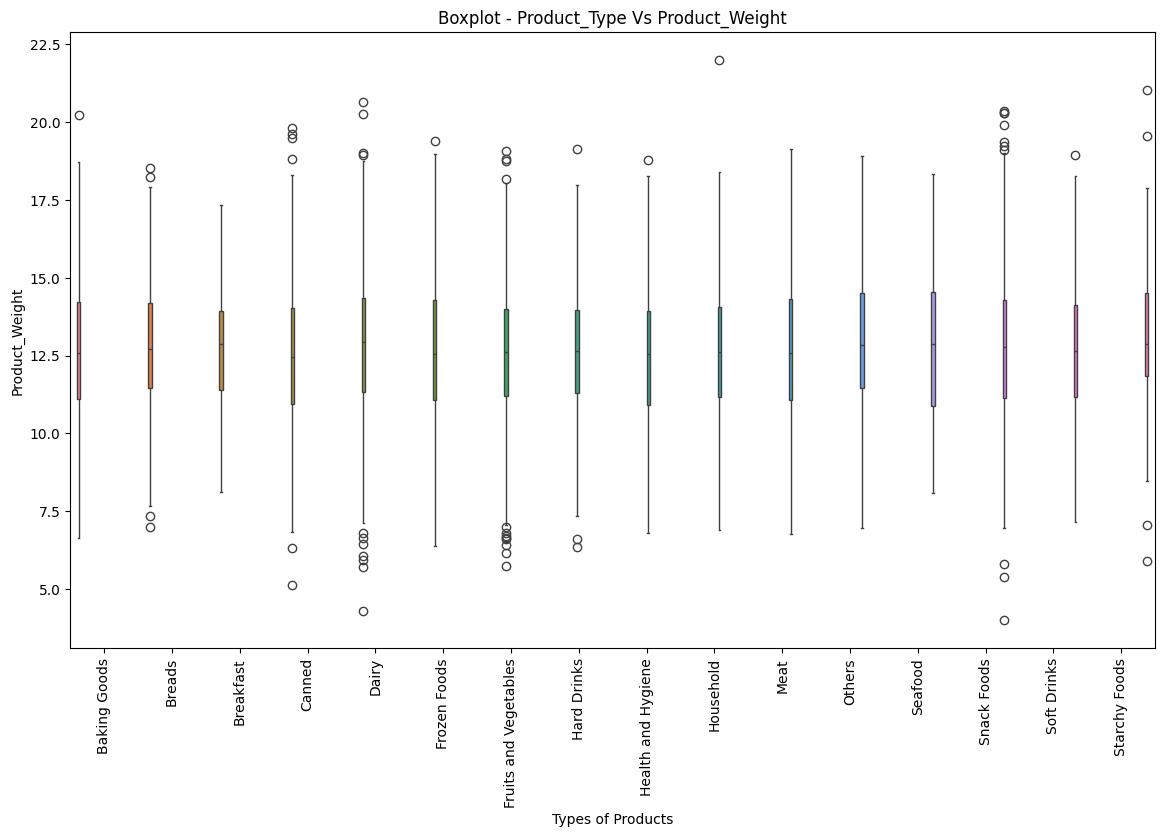

In [41]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = df, x = "Product_Type", y = "Product_Weight", hue = "Product_Type") # Boxplot with x as Product_Type, y as Product_Weight and hue as Product_Type.
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

* Most product types show similar median sales per product with outliers for the most popular Fruits and Vegetables & Snack Foods.

### **Let's find out whether there is some relationship between the weight of the product and its sugar content**

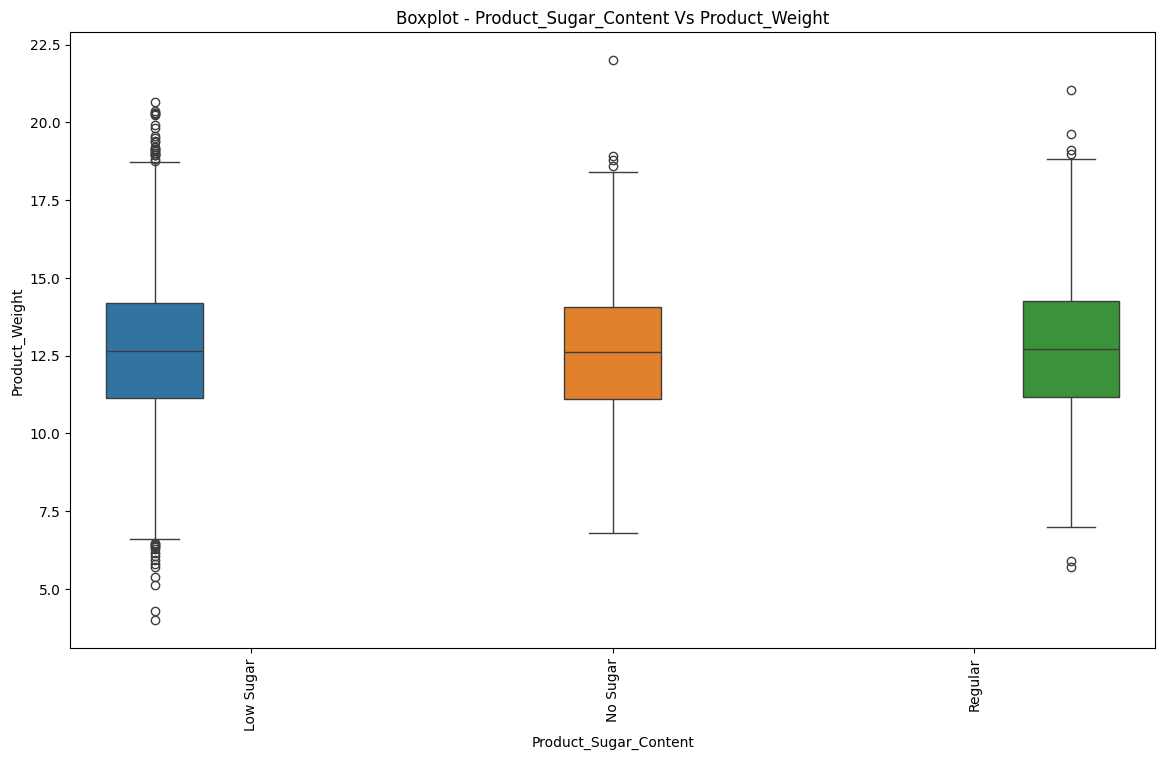

In [42]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = df, x = "Product_Sugar_Content", y = "Product_Weight", hue = "Product_Sugar_Content") # Boxplot with x as Product_Sugar_Content, y as Product_Weight and hue as Product_Sugar_Content.
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product_Sugar_Content")
plt.ylabel("Product_Weight")
plt.show()

* The median sales per product are similar for the three categories, with Low Sugar showing more outliers than the other two.

### **Let's analyze the sugar content of different product types**

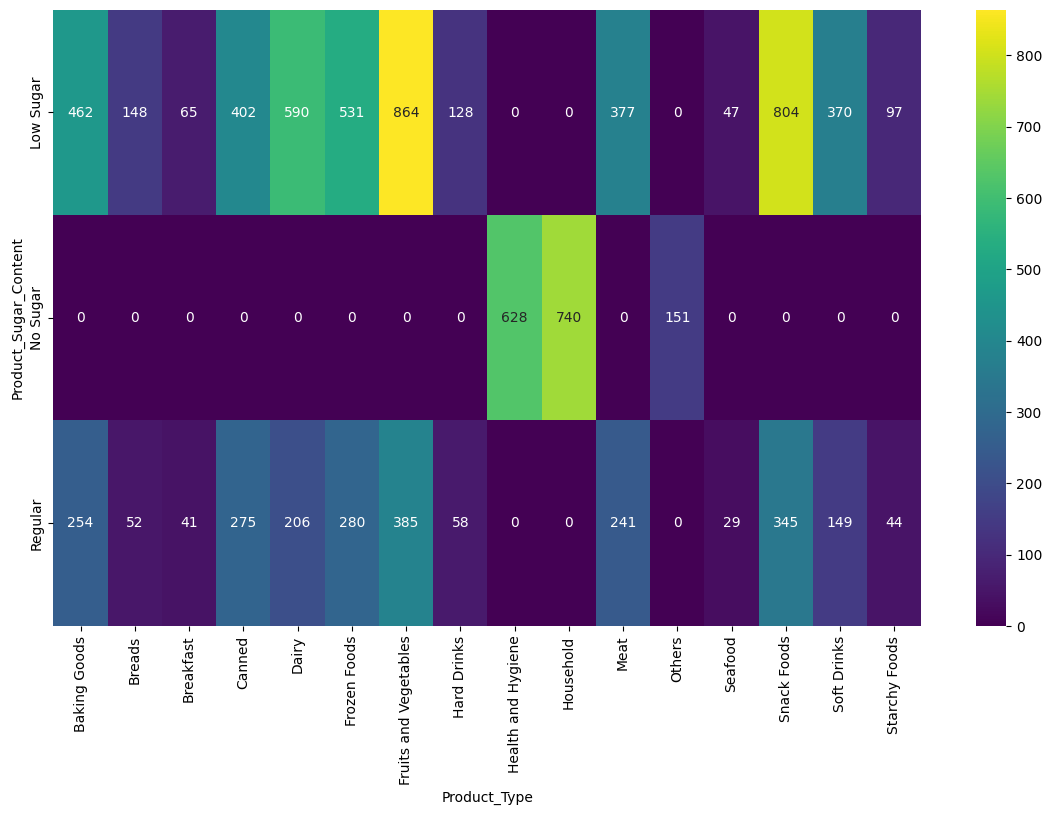

In [43]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(df["Product_Sugar_Content"], df["Product_Type"]), # Performing a crosstab operation between Product_Sugar_Content and Product_Type.
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Product_Sugar_Content")
plt.xlabel("Product_Type")
plt.show()

* Most of Low Sugar is related to Fruits and Vegetables & Snack Foods, while No Sugar is associated with Household & Health and Hygiene.

### **Let's find out how many items of each product type has been sold in each of the stores**

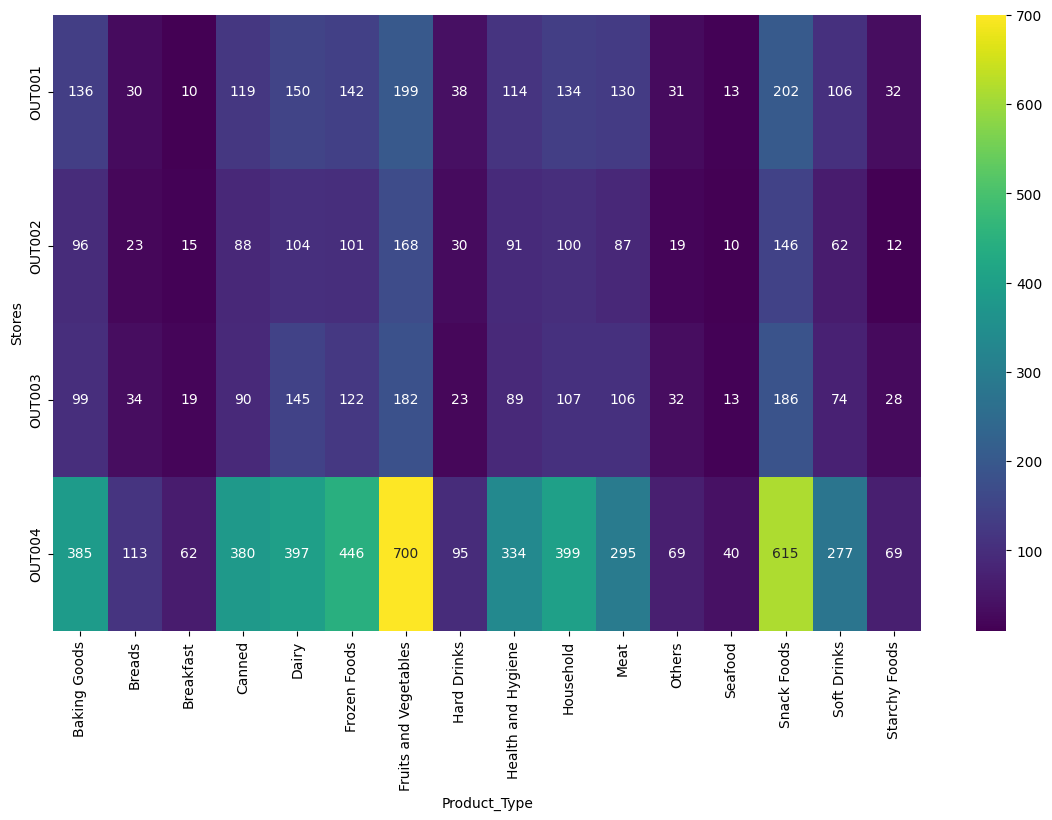

In [44]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(df["Store_Id"], df["Product_Type"]), # Performing a crosstab operation between Store_Id and Product_Type
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Stores")
plt.xlabel("Product_Type")
plt.show()

* Fruits and Vegetables & Snack Foods are mostly sold on OUT004 and in general it moves more products than other stores.

### **Different product types have different prices. Let's analyze the trend.**

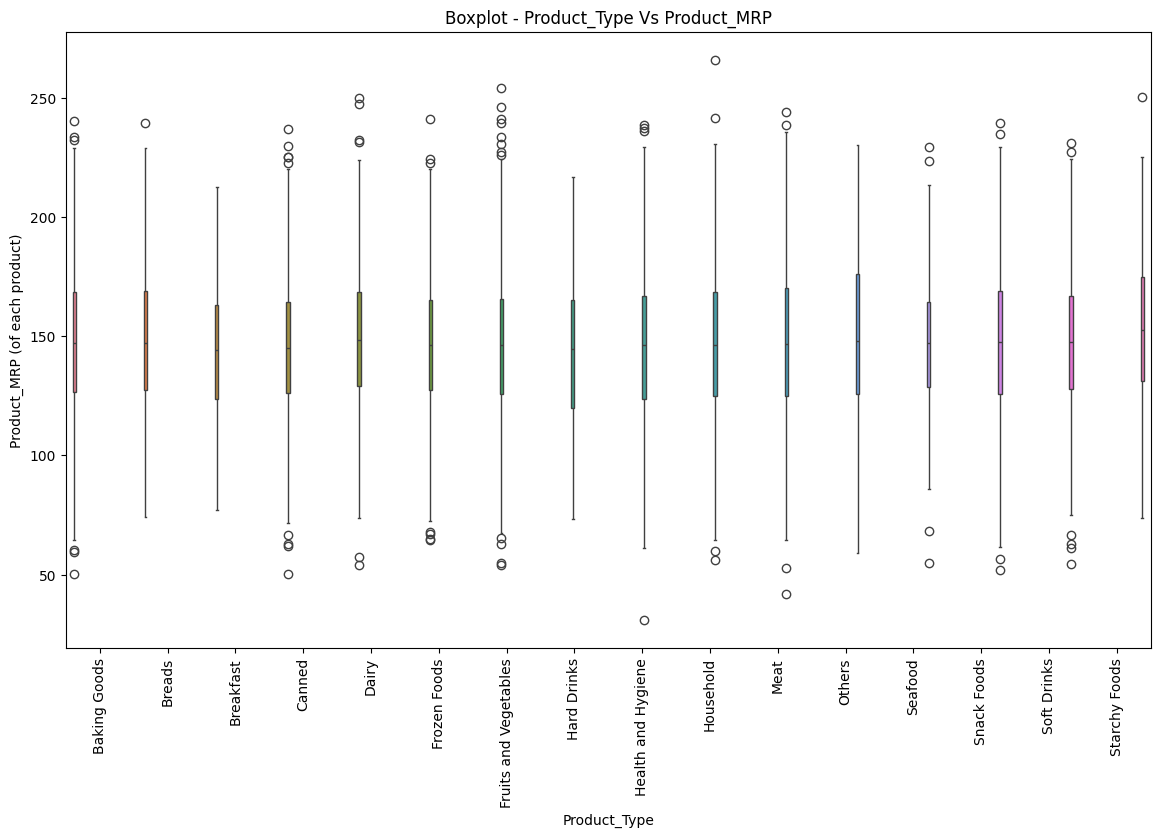

In [45]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = df, x = "Product_Type", y = "Product_MRP", hue = "Product_Type") # Boxplot with x as Product_Type, y as Product_MRP and hue as Product_Type.
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_MRP")
plt.xlabel("Product_Type")
plt.ylabel("Product_MRP (of each product)")
plt.show()

* Most product types show similar median MRP per product with outliers for the most popular Fruits and Vegetables & Snack Foods.

### **Let's find out how the Product_MRP varies with the different stores**

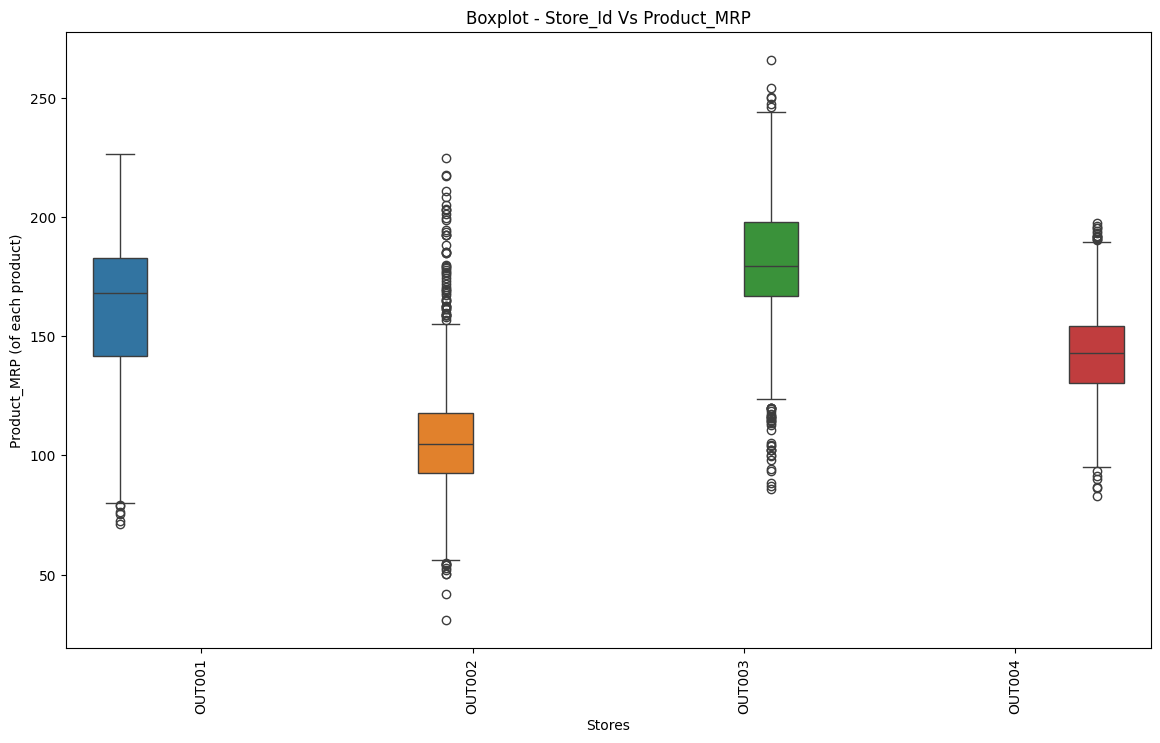

In [46]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = df, x = "Store_Id", y = "Product_MRP", hue = "Store_Id") # Boxplot with x as Store_Id, y as Product_MRP and hue as Store_Id.
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_MRP")
plt.xlabel("Stores")
plt.ylabel("Product_MRP (of each product)")
plt.show()

* Store OUT003 exhibits the highest Product MRP, along with the widest range, including some outliers.
* Store OUT001 shows a good range, with a median higher than OUT002 and OUT004.
* Store OUT004 has a median lower than OUT001 and OUT003.
* Store OUT002 consistently displays the lowest median Product MRP and the narrowest range.

### **Let's delve deeper and do a detailed analysis of each of the stores**.

#### OUT001

In [47]:
df.loc[df["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,DR1005,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,3,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT001 is a store of Supermarket Type 1 which is located in a Tier 2 city and has store size as high. It was established in 1987.
- OUT001 has sold products whose MRP range from 71 to 227.
- Snack Foods have been sold the highest number of times in OUT001.
- The revenue generated from each product at OUT001 ranges from 2300 to 5000.

In [48]:
df.loc[df["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

**OUT001 has generated total revenue of 6223113 from the sales of goods.**

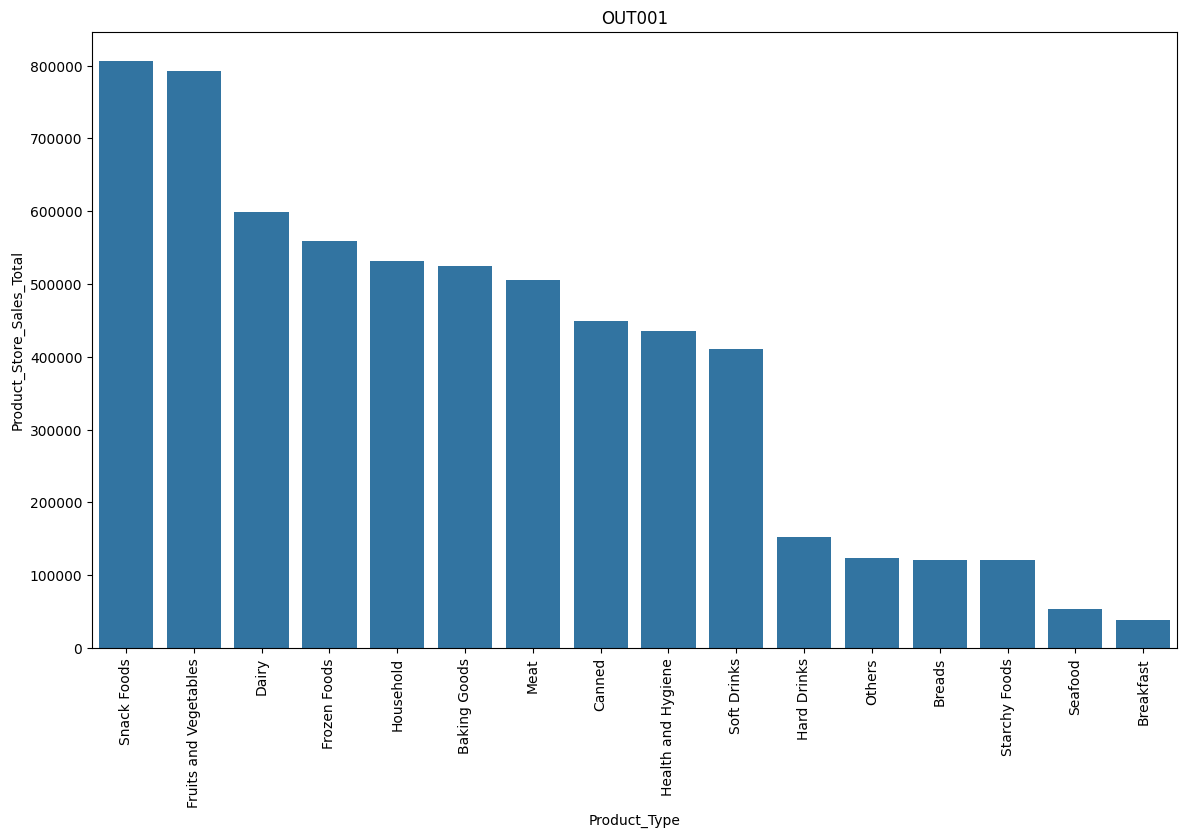

In [49]:
df_OUT001 = (
    df.loc[df["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum().sort_values(by="Product_Store_Sales_Total", ascending=False)
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total, order=df_OUT001.Product_Type)
plt.show()

- OUT001 has generated the highest revenue from the sale of fruits and vegetables and snack foods. Both the categories have contributed around 800000 each.

#### OUT002

In [50]:
df.loc[df["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,DR1157,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,3,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT002 is a food mart which is located in a Tier 3 city and has store size as small. It was established in 1998.
- OUT002 has sold products whose MRP range from 31 to 225.
- Fruits and vegetables have been sold the highest number of times in OUT002.
- The revenue generated from each product at OUT002 ranges from 33 to 2300.

In [51]:
df.loc[df["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

np.float64(2030909.72)

**OUT002 has generated total revenue of 2030910 from the sales of goods.**

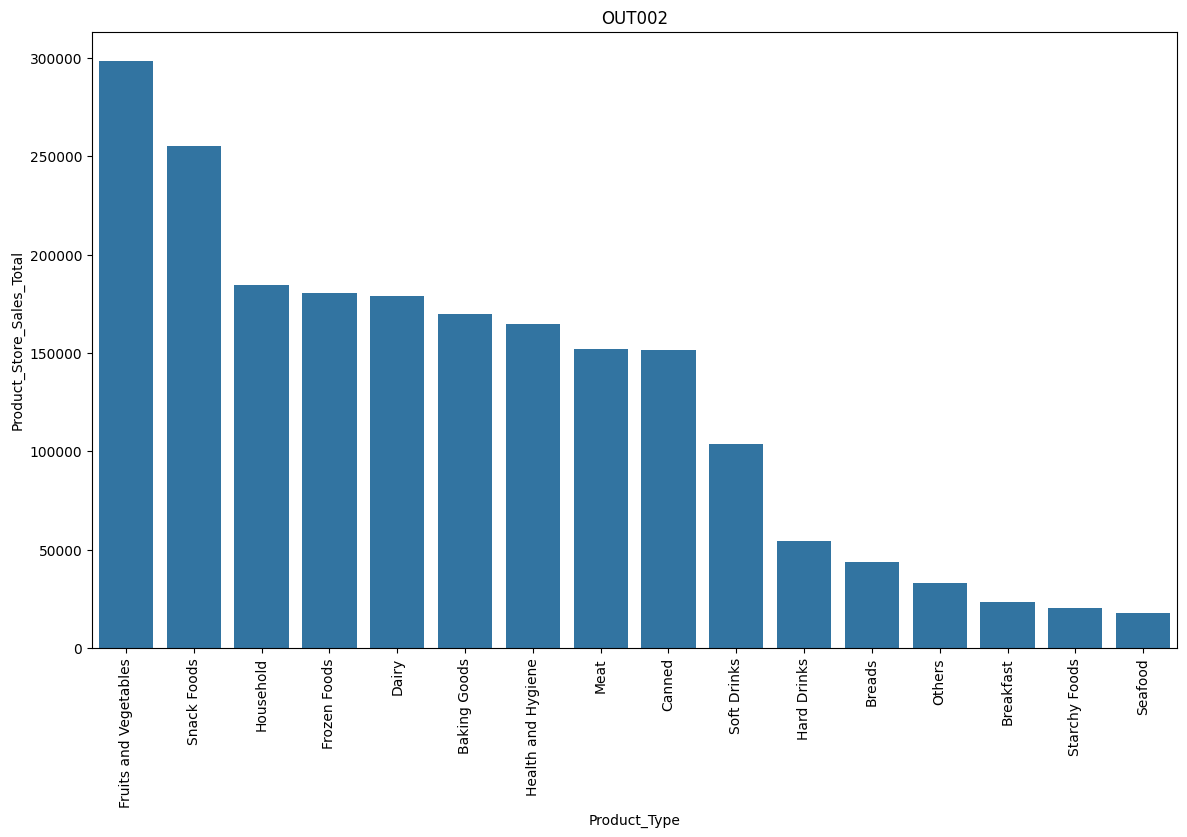

In [52]:
df_OUT002 = (
    df.loc[df["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum().sort_values(by="Product_Store_Sales_Total", ascending=False)
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=df_OUT002.Product_Type, y=df_OUT002.Product_Store_Sales_Total, order=df_OUT002.Product_Type)
plt.show()

- OUT002 has generated the highest revenue from the sale of fruits and vegetables (~ 300000) followed by snack foods (~ 250000).

#### OUT003

In [53]:
df.loc[df["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,DR1258,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,3,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT003 is a Departmental store which is located in a Tier 1 city and has store size as medium. It was established in 1999.
- OUT003 has sold products whose MRP range from 86 to 266.
- Snack Foods have been sold the highest number of times in OUT003.
- The revenue generated from each product at OUT003 ranges from 3070 to 8000.

In [54]:
df.loc[df["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

np.float64(6673457.57)

**OUT003 has generated total revenue of 6673458 from the sales of goods.**

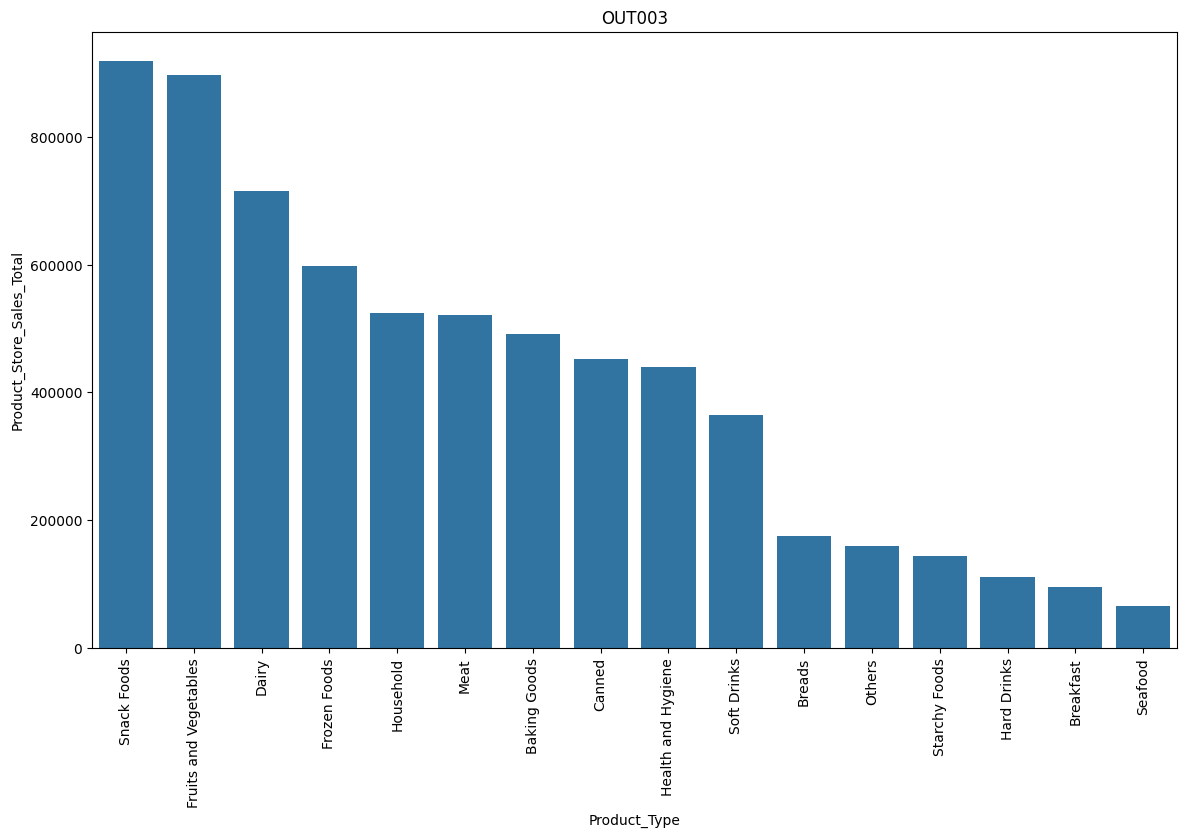

In [55]:
df_OUT003 = (
    df.loc[df["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum().sort_values(by="Product_Store_Sales_Total", ascending=False)
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=df_OUT003.Product_Type, y=df_OUT003.Product_Store_Sales_Total, order=df_OUT003.Product_Type)
plt.show()

- OUT003 has generated the highest revenue from the sale of snack foods followed by fruits and vegetables, both the categories contributing around 800000 each.

#### OUT004

In [56]:
df.loc[df["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,DR1006,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,3,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT004 is a store of Supermarket Type2 which is located in a Tier 2 city and has store size as medium. It was established in 2009.
- OUT004 has sold products whose MRP range from 83 to 198.
- Fruits and vegetables have been sold the highest number of times in OUT004.
- The revenue generated from each product at OUT004 ranges from 1561 to 5463.

In [57]:
df.loc[df["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

np.float64(15427583.43)

**OUT004 has generated total revenue of 15427583 from the sales of goods which is highest among all the 4 stores.**

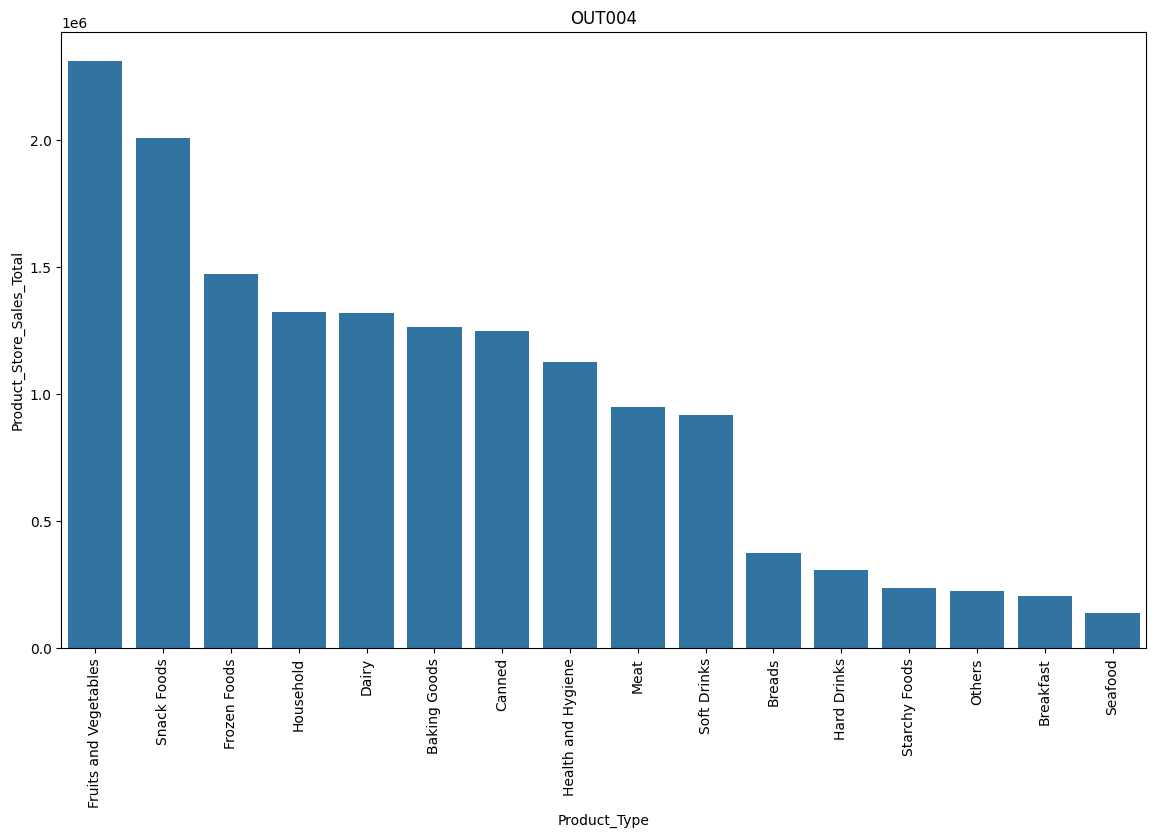

In [58]:
df_OUT004 = (
    df.loc[df["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum().sort_values(by="Product_Store_Sales_Total", ascending=False)
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=df_OUT004.Product_Type, y=df_OUT004.Product_Store_Sales_Total, order=df_OUT004.Product_Type)
plt.show()

- OUT004 has generated the highest revenue from the sale of fruits and vegetables (~ 2500000) followed by snack foods (~ 2000000).

**Let's find out the revenue generated by the stores from each of the product types**.

In [59]:
df1 = df.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


- In all the product types, the revenue generated by OUT004 has been the highest which seems quite logical since around 53% of the total products were brought from this store.
- In all the product categories, the revenue generated by OUT002 has been the lowest which seems quite obvious since it is small store in a Tier 3 city.

**Let's find out the revenue generated by the stores from products having different levels of sugar content**.

In [60]:
df2 = df.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1831924.47
9,Regular,OUT002,491988.68


- The trend is the same as that which was present in the revenue analysis of stores for product types.

# **Data Preprocessing**

## **Exploring Patterns in Product_IDs**

We can see that the Product_Id column has two characters followed by a number.

Let's delve deeper and see whether they are having any relationship with the other columns or not

In [ ]:
## extracting the first two characters from the Product_Id column and storing it in another column.
df["Product_Id_char"] = df["Product_Id"].str[:2]
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [62]:
df["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [63]:
df.loc[df.Product_Id_char == "FD", "Product_Type"].unique()

['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods', ..., 'Fruits and Vegetables', 'Breads', 'Breakfast', 'Starchy Foods', 'Seafood']
Length: 11
Categories (16, str): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']

In [ ]:
df.loc[df.Product_Id_char == "DR", "Product_Type"].unique() 

['Hard Drinks', 'Soft Drinks']
Categories (16, str): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']

In [ ]:
df.loc[df.Product_Id_char == "NC", "Product_Type"].unique() 

['Health and Hygiene', 'Household', 'Others']
Categories (16, str): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']

## **Store's Age**

A store which has been in the business for a long duration is more trustworthy than the newly established ones.

On the other hand, older stores may sometimes lack infrastructure if proper attention is not given. So let us calculate the current age of the store and incorporate that in our model.

In [ ]:
# Outlet Age.
df["Store_Age_Years"] = 2026 - df.Store_Establishment_Year

In [67]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,17
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,27
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,39
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,39
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,28


## **Grouping Product Types into Perishables and Non-Perishables.**

We have 16 different product types in our dataset.

So let us make two broad categories, perishables and non perishables, in order to reduce the number of product types.

In [68]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [69]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [70]:
df['Product_Type_Category'] = df['Product_Type'].apply(change)

In [71]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,17,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,27,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,39,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,39,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,28,Non Perishables


## **Outlier Check**

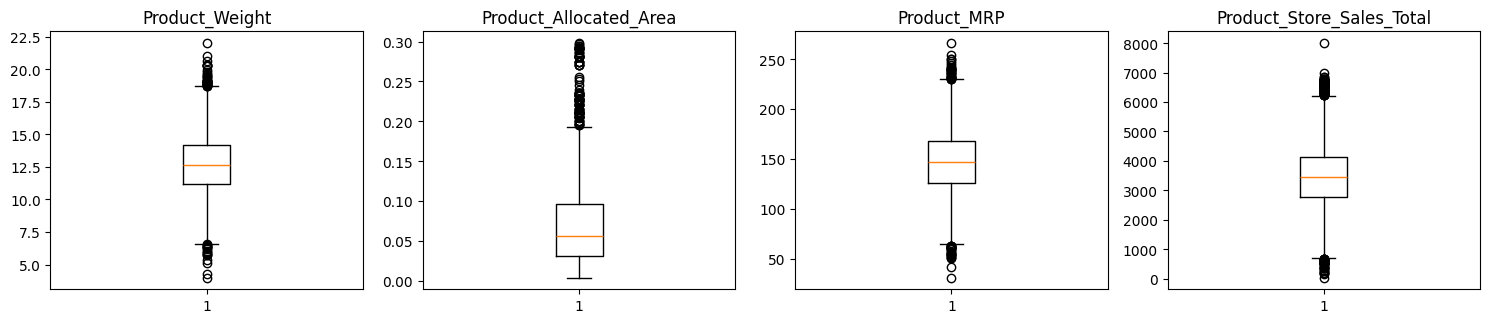

In [72]:
# outlier detection using boxplot.
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

* Although all numeric features present outliers, these will be treated by normalization.

## **Data Preparation for Modeling**

- We aim to forecast the Product_Store_Sales_Total.

- Before building the model, we'll drop unnecessary columns and encode the categorical features.

- We'll then split the data into training and testing sets to evaluate the model's performance on unseen data.

In [73]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,17,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,27,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,39,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,39,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,28,Non Perishables


Let's remove the columns that are not required.

In [74]:
df = df.drop(["Product_Id","Product_Type","Store_Id","Store_Establishment_Year"], axis=1) # Dropping columns "Product_Id","Product_Type","Store_Id","Store_Establishment_Year".

In [75]:
df.shape

(8763, 11)

In [76]:
df.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,17,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,27,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,39,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,39,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,28,Non Perishables


In [77]:
# Separating features and the target column.
X = df.drop("Product_Store_Sales_Total", axis=1) 
y = df["Product_Store_Sales_Total"] 

In [78]:
# Splitting the data into train and test sets in 70:30 ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, shuffle=True 
)

In [79]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

### **Data Pre-processing Pipeline**

In [80]:
numerical_features = X.select_dtypes(include=['number']).columns.tolist()

numerical_features

['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']

In [81]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['Product_Sugar_Content',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Id_char',
 'Product_Type_Category']

In [82]:
# Create a preprocessing pipeline for the numerical and categorical features.

preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

# **Model Building**

**Model Objective:**

* Create and deploy a predictive model based on historical sales data, to accurately forecast sales revenues.

**General Model:**

* Two models will be selected from the following list: **1. Decision Tree, 2. Bagging, 3. Random Forest, 4. Ada Boost, 5. Gradient Boosting, and 6. XGBoost**.
* The selected models will be  trained, tuned and the best will be serialized to be deployed.

## Define functions for Model Evaluation

Metrics Measured for Regression Models:

* R-squared (R²) - Proportion of variance in the target that is predictable from the independent variables. An R-squared value close to 1 indicates that a large proportion of the variance is explained by the model, while a value close to 0 suggests little explanatory power.

* Adjusted R-squared - R² adjusted for number of predictors to penalize unnecessary variables. Helps compare models with different numbers of features and avoid overfitting. It should always be lower than or equal to R².

* Mean Absolute Error (MAE) - Average absolute difference between predicted and actual values. This metric is intuitive and provides a straightforward way to compare models. A model with a lower MAE is considered better as it indicates smaller prediction errors.

* Root Mean Squared Error (RMSE) - Square root of average squared prediction error. Penalizes large errors heavily; useful when large mistakes are costly.

* Mean Absolute Percentage Error (MAPE) - Express prediction errors as a percentage of the actual values. This normalization allows for comparisons across different scales and datasets.


In [83]:
# function to compute adjusted R-squared.
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model.
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables.
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared.
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared.
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE.
    mae = mean_absolute_error(target, pred)  # to compute MAE.
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE.

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

* The 2 selected models will be:  **4)AdaBooster Regressor** and **6)XGBoost Regressor**.

## AdaBoost Regressor

In [84]:
ab_regressor = AdaBoostRegressor(random_state=1)
ab_regressor = make_pipeline(preprocessor,ab_regressor)
ab_regressor.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('adaboostregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

### Checking model performance on training set

In [85]:
ab_regressor_model_train_perf = model_performance_regression(ab_regressor, X_train, y_train)
ab_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,506.922593,400.703461,0.772893,0.772522,0.135528


### Checking model performance on test set

In [86]:
ab_regressor_model_test_perf = model_performance_regression(ab_regressor, X_test, y_test)
ab_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,524.268614,413.25125,0.759814,0.758896,0.158491


**Initial AdaBoost Regressor Performance (Default Parameters)**

Let's first examine the performance metrics of the AdaBoost Regressor using its default configuration on both the training and test datasets:

*   **Training Set Performance (Default AdaBoost):**
    *   **RMSE**: 506.92
    *   **MAE**: 400.70
    *   **R-squared**: 0.7729
    *   **Adj. R-squared**: 0.7725
    *   **MAPE**: 0.1355

*   **Testing Set Performance (Default AdaBoost):**
    *   **RMSE**: 524.27
    *   **MAE**: 413.25
    *   **R-squared**: 0.7598
    *   **Adj. R-squared**: 0.7589
    *   **MAPE**: 0.1585

**Interpretation of Default AdaBoost Performance:**

1.  **R-squared and Adjusted R-squared:** The R-squared value of approximately 0.77 on the training set indicates that about 77% of the variance in `Product_Store_Sales_Total` can be explained by the features used in the model. This is a reasonably good fit, suggesting the model captures a significant portion of the underlying relationships in the training data. On the test set, the R-squared drops slightly to around 0.76. This minimal drop (around 1.3%) is a positive sign, indicating that the model generalizes fairly well to unseen data and is not severely overfitting. The Adjusted R-squared values closely follow the R-squared values, as expected, confirming the explanatory power considering the number of features.

2.  **RMSE (Root Mean Squared Error):** The RMSE measures the square root of the average of the squared errors. It gives a relatively high weight to large errors. A training RMSE of 506.92 means that, on average, the model's predictions deviate from the actual sales by approximately 507 units. On the test set, this increases slightly to 524.27. While this increase is minor and suggests decent generalization, an RMSE of over 500 units might be considered large depending on the scale of the target variable (`Product_Store_Sales_Total`), which ranges up to 8000. This implies that while the model captures trends, its absolute prediction errors can still be substantial in some cases.

3.  **MAE (Mean Absolute Error):** The MAE represents the average of the absolute differences between predictions and actual values. It is less sensitive to outliers than RMSE. With an MAE of 400.70 on the training set and 413.25 on the test set, the average absolute prediction error is around 400-413 units. This again points to a consistent level of error across both datasets, supporting the generalization claim. However, similar to RMSE, an average absolute error of over 400 could impact business decisions if precise sales figures are required.

4.  **MAPE (Mean Absolute Percentage Error):** MAPE expresses the error as a percentage of the actual values, making it easier to interpret across different scales. A training MAPE of 0.1355 (13.55%) and a testing MAPE of 0.1585 (15.85%) indicate that, on average, the model's predictions are off by about 13.5% to 15.8%. This level of percentage error, while not extremely high, could be significant for profit margins or inventory management, especially for high-volume or low-margin products. The slight increase in MAPE from training to testing is also a normal indication of generalization.


---

## XGBoost Regressor

In [87]:
xgb_estimator = XGBRegressor(random_state=1)
xgb_estimator = make_pipeline(preprocessor,xgb_estimator)
xgb_estimator.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Checking model performance on training set

In [88]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
xgb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,118.628943,58.099567,0.987563,0.987542,0.019789


### Checking model performance on test set

In [89]:
xgb_estimator_model_test_perf = model_performance_regression(xgb_estimator, X_test, y_test)
xgb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.728392,138.777589,0.915627,0.915305,0.056883


**Initial XGBoost Regressor Performance (Default Parameters)**

Let's first review the performance metrics for the XGBoost Regressor when using its default parameters on both the training and test datasets:

*   **Training Set Performance (Default XGBoost):**
    *   **RMSE**: 118.63
    *   **MAE**: 58.10
    *   **R-squared**: 0.9876
    *   **Adj. R-squared**: 0.9875
    *   **MAPE**: 0.0198

*   **Testing Set Performance (Default XGBoost):**
    *   **RMSE**: 310.73
    *   **MAE**: 138.78
    *   **R-squared**: 0.9156
    *   **Adj. R-squared**: 0.9153
    *   **MAPE**: 0.0569

**Interpretation of Default XGBoost Performance:**

1.  **R-squared and Adjusted R-squared:** The R-squared value of approximately 0.9876 on the training set is exceptionally high, indicating that the model explains nearly 99% of the variance in `Product_Store_Sales_Total` on the data it was trained on. This suggests an excellent fit to the training data. However, on the test set, the R-squared drops to 0.9156. While still very good, this notable drop (around 7.2 percentage points) from training to testing strongly suggests **overfitting**. The model has learned the training data too well, including its noise and specific patterns, and struggles to generalize as effectively to unseen data.

2.  **RMSE (Root Mean Squared Error):** The training RMSE of 118.63 is remarkably low, indicating very small prediction errors on the training set. However, the test RMSE significantly increases to 310.73. This substantial increase (more than double) reinforces the overfitting observation. While an RMSE of ~311 is much better than AdaBoost's ~524, the discrepancy between training and test performance indicates that the model's reliability on new data might not be as high as the training metrics suggest.

3.  **MAE (Mean Absolute Error):** Similar to RMSE, the MAE shows a stark contrast between training (58.10) and testing (138.78). An average absolute error of approximately 58 units on the training data is excellent. However, this more than doubles on the test set, highlighting that the model's average prediction accuracy deteriorates significantly when encountering new data points. This also points to overfitting.

4.  **MAPE (Mean Absolute Percentage Error):** The training MAPE is a very low 0.0198 (1.98%), implying predictions are off by less than 2% on average for the training data. This is an outstanding result. However, on the test set, the MAPE rises to 0.0569 (5.69%). While a MAPE of under 6% is generally considered very good in many business contexts, the almost threefold increase from training to testing is a clear indicator of the model's reduced generalization capability due to overfitting.

In summary, the default XGBoost Regressor demonstrates exceptionally high performance on the training data, but exhibits clear signs of overfitting, as evidenced by the significant degradation in all metrics when evaluated on the test set. The model captures the underlying patterns well but also memorizes the training data, leading to less reliable predictions on unseen data.

---

# **Model Performance Improvement - Hyperparameter Tuning**

## Hyperparameter Tuning - AdaBoost Regressor

In [90]:
# Choose the type of classifier.
ab_tuned = AdaBoostRegressor(random_state=1)
ab_tuned = make_pipeline(preprocessor,ab_tuned)
# # Grid of parameters to choose from
parameters = {
     "adaboostregressor__n_estimators": [50, 75, 85, 100], 
     "adaboostregressor__learning_rate": [1.0, 0.5, 0.1, 0.01], 
 }


# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
ab_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
ab_tuned.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('adaboostregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

### Checking model performance on training set

In [91]:
ab_tuned_model_train_perf = model_performance_regression(ab_tuned, X_train, y_train)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,506.922593,400.703461,0.772893,0.772522,0.135528


### Checking model performance on test set

In [92]:
ab_tuned_model_test_perf = model_performance_regression(ab_tuned, X_test, y_test)
ab_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,524.268614,413.25125,0.759814,0.758896,0.158491


**AdaBoost Regressor Performance After Hyperparameter Tuning**

To improve the AdaBoost Regressor's performance, through hyperparameter tuning using `GridSearchCV`, the parameters to be explored are `n_estimators` (number of boosting stages) and `learning_rate`.

*   **Training Set Performance (Tuned AdaBoost):**
    *   **RMSE**: 506.92
    *   **MAE**: 400.70
    *   **R-squared**: 0.7729
    *   **Adj. R-squared**: 0.7725
    *   **MAPE**: 0.1355

*   **Testing Set Performance (Tuned AdaBoost):**
    *   **RMSE**: 524.27
    *   **MAE**: 413.25
    *   **R-squared**: 0.7598
    *   **Adj. R-squared**: 0.7589
    *   **MAPE**: 0.1585

**Analysis of Tuned AdaBoost Performance and Comparison:**

The tuned AdaBoost Regressor showed *no improvement* from the regular (default) model. This is evident from the fact that all performance metrics (RMSE, MAE, R-squared, Adj. R-squared, and MAPE) for both the training and test sets are identical to those of the default AdaBoost model. The output of the `GridSearchCV` operation confirms that the best parameters found by the search were effectively the same as or equivalent to the default parameters (or at least, the tuning process did not yield a combination that improved the `r2_score` beyond the default's performance).

**Possible Reasons for No Improvement:**

1.  **Limited Search Space:** The `parameters` dictionary defined for `GridSearchCV` (`"adaboostregressor__n_estimators": [50, 75, 85, 100]`, `"adaboostregressor__learning_rate": [1.0, 0.5, 0.1, 0.01]`) might have been too restricted. It's possible that the optimal hyperparameters for this dataset lie outside these specific ranges or require different combinations of other parameters not included in the search (e.g., `loss` function, `base_estimator` parameters).
2.  **Default Optimality:** For this specific dataset and feature set, the default hyperparameters of AdaBoost might already be quite effective, or at least locally optimal within the defined search grid, meaning no significant gains were possible with the chosen tuning approach.
3.  **Dataset Characteristics:** AdaBoost's performance is sensitive to noisy data and outliers, as it focuses heavily on misclassified instances. If the dataset contains a high degree of noise or numerous impactful outliers (which the EDA suggested were present in several numeric features), AdaBoost might struggle to improve beyond a certain point, regardless of hyperparameter tuning, if these characteristics are not adequately addressed by its boosting mechanism.
4.  **Base Estimator:** By default, AdaBoost uses `DecisionTreeRegressor(max_depth=3)` as its base estimator. The performance is heavily reliant on this base learner. It's possible that a different `base_estimator` or tuning its parameters within the AdaBoost framework could yield better results.

---

## Hyperparameter Tuning - XGBoost Regressor

In [93]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=1)
xgb_tuned = make_pipeline(preprocessor,xgb_tuned)

# Grid of parameters to choose from
parameters = {
    "xgbregressor__n_estimators": [50, 75, 100, 125],
    "xgbregressor__subsample": [0.5, 0.7, 0.8, 1.0], 
    "xgbregressor__gamma": [0, 1, 3, 5, 8], 
    "xgbregressor__colsample_bytree": [0.3, 0.5, 0.7, 1.0], 
    "xgbregressor__colsample_bylevel": [0.3, 0.5, 0.7, 1.0], 
}

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

### Checking model performance on training set

In [94]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,429.408064,315.613944,0.837037,0.836771,0.116627


### Checking model performance on test set

In [95]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,457.151858,335.477257,0.817375,0.816677,0.139808


**XGBoost Regressor Performance After Hyperparameter Tuning**

To address the overfitting issue and potentially improve generalization, hyperparameter tuning was performed for the XGBoost Regressor. A `GridSearchCV` approach was used, exploring parameters such as `n_estimators`, `subsample`, `gamma`, `colsample_bytree`, and `colsample_bylevel`.

*   **Training Set Performance (Tuned XGBoost):**
    *   **RMSE**: 429.41
    *   **MAE**: 315.61
    *   **R-squared**: 0.8370
    *   **Adj. R-squared**: 0.8368
    *   **MAPE**: 0.1166

*   **Testing Set Performance (Tuned XGBoost):**
    *   **RMSE**: 457.15
    *   **MAE**: 335.48
    *   **R-squared**: 0.8174
    *   **Adj. R-squared**: 0.8167
    *   **MAPE**: 0.1398

**Analysis of Tuned XGBoost Performance and Comparison to Default:**

1.  **R-squared and Adjusted R-squared:** The R-squared values for the tuned XGBoost are 0.8370 on the training set and 0.8174 on the test set. Compared to the default model, the training R-squared has decreased significantly (from ~0.98 to ~0.83), which initially might seem like a step backward. However, the crucial observation is the much smaller gap between the training and test R-squared (only about 2 percentage points, compared to 7.2 points for the default model). This indicates that the tuning process successfully reduced overfitting and improved the model's ability to generalize to new data.

2.  **RMSE and MAE:** The tuned model shows higher RMSE (429.41 train, 457.15 test) and MAE (315.61 train, 335.48 test) values on both sets compared to the default XGBoost's training performance. However, these metrics are significantly better than the default XGBoost's *test* performance (RMSE 310.73, MAE 138.78). More importantly, the difference between training and test RMSE/MAE is much smaller, suggesting a more robust and generalized model.

3.  **MAPE:** The tuned model's MAPE is 0.1166 (11.66%) on the training set and 0.1398 (13.98%) on the test set. While these values are higher than the default model's training MAPE, they represent a much more realistic and consistent performance on unseen data. The difference between training and test MAPE is only about 2.3 percentage points, indicating much better generalization.

In essence, hyperparameter tuning for XGBoost achieved its objective: **it successfully mitigated overfitting**, leading to a model with slightly lower but more consistent R-squared, RMSE, MAE, and MAPE values across both training and test sets. The tuned model, despite having a lower R-squared on the training set than the default, provides a much more reliable prediction of performance on unseen data.

---

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [96]:
 # Training performance comparison.

models_train_comp_df = pd.concat(
    [
        ab_regressor_model_train_perf.T, 
        ab_tuned_model_train_perf.T, 
        xgb_estimator_model_train_perf.T, 
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = ["AdaBoost", "Tuned Ada","XGBoost", "Tuned XGBoost"] 

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost,Tuned Ada,XGBoost,Tuned XGBoost
RMSE,506.922593,506.922593,118.628943,429.408064
MAE,400.703461,400.703461,58.099567,315.613944
R-squared,0.772893,0.772893,0.987563,0.837037
Adj. R-squared,0.772522,0.772522,0.987542,0.836771
MAPE,0.135528,0.135528,0.019789,0.116627


In [97]:
 # Testing performance comparison.

models_test_comp_df = pd.concat(
    [
        ab_regressor_model_test_perf.T, 
        ab_tuned_model_test_perf.T, 
        xgb_estimator_model_test_perf.T, 
        xgb_tuned_model_test_perf.T, 
    ],
    axis=1,
)

models_test_comp_df.columns = ["AdaBoost", "Tuned Ada","XGBoost", "Tuned XGBoost"]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,AdaBoost,Tuned Ada,XGBoost,Tuned XGBoost
RMSE,524.268614,524.268614,310.728392,457.151858
MAE,413.251250,413.251250,138.777589,335.477257
R-squared,0.759814,0.759814,0.915627,0.817375
Adj. R-squared,0.758896,0.758896,0.915305,0.816677
MAPE,0.158491,0.158491,0.056883,0.139808


* The AdaBoost Regressor, both in its default and 'tuned' (unimproved) forms, provides a consistent, albeit moderate, level of predictive power. It explains approximately 76-77% of the variance in sales and exhibits average prediction errors in the range of 13.5% to 15.8%. While it demonstrates good generalization capabilities (low difference between training and test performance), its error magnitudes might not be sufficient for business applications demanding high precision.

* Crucially, the comparison with the XGBoost models highlights AdaBoost's limitations for this particular problem. The regular XGBoost significantly outperforms AdaBoost across all metrics, and the tuned XGBoost achieves an even higher R-squared (around 0.82 on the test set) with considerably lower error metrics (e.g., MAPE around 5-13% for XGBoost vs. 15-16% for AdaBoost). This suggests that for this sales forecasting task, models like XGBoost, which are generally more robust and powerful, are more appropriate.

* The tuned XGBoost model explained over 81% of the variance in sales and had an average percentage error of around 14% on unseen data. This level of performance makes it a strong candidate for deployment, providing SuperKart with valuable insights for inventory management and sales strategy.

**Comparison to AdaBoost Regressor:**

When comparing the tuned XGBoost Regressor to the AdaBoost Regressor (both default and tuned, which performed identically):

*   **R-squared:** Tuned XGBoost achieved an R-squared of 0.8174 on the test set, significantly outperforming AdaBoost's 0.7598. This means XGBoost explains a considerably larger proportion of the variance in sales.
*   **RMSE and MAE:** Tuned XGBoost's test RMSE of 457.15 and MAE of 335.48 are better than AdaBoost's test RMSE of 524.27 and MAE of 413.25. This indicates that XGBoost generally makes smaller absolute errors in its predictions.
*   **MAPE:** Tuned XGBoost's test MAPE of 0.1398 (13.98%) is also better than AdaBoost's 0.1585 (15.85%). While the percentage difference seems small, in business contexts, even a few percentage points of accuracy can translate into significant financial implications.

Overall, XGBoost, especially after tuning, clearly demonstrates superior predictive power and generalization compared to the AdaBoost Regressor for this sales forecasting task. This aligns with the general understanding that gradient boosting machines like XGBoost are often more robust and achieve higher performance than adaptive boosting methods like AdaBoost, particularly on complex datasets.


## Final Model Selection

##### The model selected for deployment is: **Tuned XGBoost**.

In [98]:
best_model = xgb_tuned

## Serialization

In [99]:
# Create a folder for storing the files needed for web app deployment.
os.makedirs("backend_files", exist_ok=True)

In [100]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps.
saved_model_path = "backend_files/Super_Kart_Model_v1_0.joblib" # Name of the model.

In [ ]:
# Saving the best trained model pipeline using joblib.
joblib.dump(best_model, saved_model_path) # Best model.

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/Super_Kart_Model_v1_0.joblib


In [ ]:
# Loading the saved model pipeline from the file.
saved_model = joblib.load("backend_files/Super_Kart_Model_v1_0.joblib") # Name of saved model.

# Confirm the model is loaded.
print("Model loaded successfully.")

Model loaded successfully.


In [103]:
saved_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [104]:
saved_model.predict(X_test) 

array([3494.3806, 5094.9434, 5204.5366, ..., 3477.7856, 3201.5972,
       3522.7844], shape=(2629,), dtype=float32)

- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Flask Web Framework


In [105]:
%%writefile backend_files/app.py

# Import necessary libraries.
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API.

# Initialize Flask app with a name
superkart_api = Flask("Super Kart Sales Forecast") # Name of the app.

# Load the trained sales prediction model.
model = joblib.load("Super_Kart_Model_v1_0.joblib")

# Define a route for the home page.
@superkart_api.get('/')
def home():
    return "Welcome To SuperKart's Sales Forecast" # Welcome message.

# Define an endpoint to predict sales.
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request.
    data = request.get_json()

    # Extract relevant customer features from the input data. The order of the column names matters.
    sample = {
        'Product_Weight': data['Product_Weight'],
        'Product_Sugar_Content': data['Product_Sugar_Content'],
        'Product_Allocated_Area': data['Product_Allocated_Area'],
        'Product_MRP': data['Product_MRP'],
        'Store_Size': data['Store_Size'],
        'Store_Location_City_Type': data['Store_Location_City_Type'],
        'Store_Type': data['Store_Type'],
        'Product_Id_char': data['Product_Id_char'],
        'Store_Age_Years': data['Store_Age_Years'],
        'Product_Type_Category': data['Product_Type_Category']
    }

    # Convert the extracted data into a DataFrame.
    input_data = pd.DataFrame([sample])

    # Make a sales prediction using the trained model.
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response.
    return jsonify({'Sales': prediction})

# Define an endpoint to predict sales for a batch of data.
@superkart_api.post('/v1/batch')
def predict_sales_batch():
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the file into a DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for the batch data and convert raw predictions into a readable format
    predictions = model.predict(input_data).tolist()

    output_dict = [{'Index':index, 'Predicted_Sales': sales}
        for index, sales in zip(input_data.idex, predictions)]

    return jsonify(output_dict)


# Run the Flask app in debug mode.
if __name__ == '__main__':
    superkart_api.run(debug=True)

Writing backend_files/app.py


## Dependencies File

In [106]:
# Checking versions of packages installed in the environment.

!pip list

Package                 Version
----------------------- -----------
absl-py                 2.4.0
annotated-doc           0.0.4
anyio                   4.13.0
asttokens               3.0.1
astunparse              1.6.3
audioop-lts             0.2.2
audioread               3.1.0
bokeh                   3.9.0
catboost                1.2.10
category_encoders       2.9.0
certifi                 2026.1.4
cffi                    2.0.0
charset-normalizer      3.4.4
click                   8.3.1
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
Cython                  3.2.4
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
filelock                3.29.0
flatbuffers             25.12.19
fonttools               4.61.1
fsspec                  2026.4.0
gast                    0.7.0
gensim                  4.4.0
gensin                  5
google-pasta            0.2.0
graphviz             

In [107]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.8.0
xgboost==3.2.0
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==26.0.0
requests==2.28.1
uvicorn[standard]

Writing backend_files/requirements.txt


## Dockerfile

In [108]:
%%writefile backend_files/Dockerfile
FROM python:3.12-slim

# Set the working directory inside the container.
WORKDIR /app # Setting the working directory.

# Copy all files from the current directory to the container's working directory.
COPY . . 

# Install dependencies from the requirements file without using cache to reduce image size.
RUN pip install --no-cache-dir --upgrade -r requirements.txt # Installing dependencies.

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `Super_Kart_Sales_Estimator`).
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

**Note**: We are creating a Hugging Face Docker Space for our backend using the Hugging Face Hub API. This automates the space creation process and enables seamless deployment of our Flask app.

In [ ]:
# Import the login function from the huggingface_hub library.
from huggingface_hub import login

# Login to your Hugging Face account using your access token.
# Replace "YOUR_HUGGINGFACE_TOKEN" with your actual token.
#login(token="YOUR_HUGGINGFACE_TOKEN")  # You can get your token from https://huggingface.co/settings/tokens.
login(token="MY_HUGGINGFACE_TOKEN") # HF access token.

# Import the create_repo function from the huggingface_hub library.
from huggingface_hub import create_repo

In [110]:
# Try to create the repository for the Hugging Face Space.
try:
    create_repo("Backend-SK",  # Name of the repository.
        repo_type="space",  # Specify the repository type as "space".
        space_sdk="docker",  # Specify the space SDK as "docker".
        private=False  # Set to public space.
    )
except Exception as e:
    # Handle potential errors during repository creation.
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a13b1fd-48c8b65718ff1ef95b944345;78f2af90-2ff9-4b85-a04e-bd2ee2613e04)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this space repo: rarriagao/Backend-SK


## Uploading Files to Hugging Face Space (Docker Space)

**Note**: Before running the code below, ensure that the serialized ML model has been uploaded in to `backend_files` folder.

In [ ]:
# for hugging face space authentication to upload files.

access_key = "MY_HUGGINGFACE_TOKEN"  # HF access token.
repo_id = "rarriagao/Backend-SK"  # Repo id.

# Login to Hugging Face platform with the access token.
login(token=access_key)

# Initialize the API.
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files.
api.upload_folder(
    folder_path="backend_files",
    repo_id=repo_id,  # Hugging face space id.
    repo_type="space",  # Hugging face repo type "space".
)

Processing Files (1 / 1): 100%|██████████| 67.2kB / 67.2kB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/rarriagao/Backend-SK/commit/39db14e13effd893341e291082becf44c3f3461a', commit_message='Upload folder using huggingface_hub', commit_description='', oid='39db14e13effd893341e291082becf44c3f3461a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/rarriagao/Backend-SK', endpoint='https://huggingface.co', repo_type='space', repo_id='rarriagao/Backend-SK'), pr_revision=None, pr_num=None)

### Backend successfully created at [https://huggingface.co/spaces/rarriagao/Backend-SK](https://huggingface.co/spaces/rarriagao/Backend-SK)

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [112]:
# Create a folder for storing the files needed for frontend UI deployment.
os.makedirs("frontend_files", exist_ok=True)

In [ ]:
%%writefile frontend_files/app.py

import streamlit as st
import pandas as pd
import requests

st.title("SuperKart Sales Forecast") #Complete the code to define the title of the app.
st.write("This tool predicts potential sales. Enter the required information below.")

# Batch Prediction
st.subheader("Online Prediction")


# Input fields for product and store data.
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66, help="Weight of the product in pounds (numerical value)")
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=0.068, 
    help="Ratio of the allocated display area of each product to the total display area of all the products in a store")
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=116.7, help="Maximum retail price of each product (numerical value)")
Store_Size = st.selectbox("Store Size", [ "Small", "Medium", "High"])
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])
Product_Id_char = st.selectbox("Product Id Char", ["FD", "NC", "DR"])
Store_Age_Years = st.number_input("Store Age (Years)", min_value=0, value=17, help="Age of the store, in years")
Product_Type_Category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Id_char": Product_Id_char,
    "Store_Age_Years": Store_Age_Years,
    "Product_Type_Category": Product_Type_Category
}

if st.button("Predict", type='primary'):
    response = requests.post("https://rarriagao-Backend-SK.hf.space/v1/predict", json=product_data)    # Defining the endpoint.
    if response.status_code == 200:
        result = response.json()
        predicted_sales = result["Sales"]
        st.write(f"Predicted Product Store Sales Total:  {predicted_sales:.2f}")
    else:
        st.error("Error in API request")

# Batch Prediction
st.subheader("Batch Prediction")

file = st.file_uploader("Upload CSV file", type=["csv"])
if file is not None:
    if st.button("Predict for Batch", type='primary'):
        response = requests.post("https://rarriagao-Backend-SK.hf.space/v1/batch", files={"file": file})
        if response.status_code == 200:
            result = response.json()
            st.header("Batch Prediction Results")
            st.write(result)
        else:
            st.error("Error in API request")        

Writing frontend_files/app.py


## Dependencies File

In [114]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.32.3
streamlit==1.45.0

Writing frontend_files/requirements.txt


## Dockerfile

In [115]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed.
FROM python:3.9-slim

# Set the working directory inside the container to /app.
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory.
COPY . .

# Install Python dependencies listed in requirements.txt.
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally.
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions.

Writing frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
access_key = "MY_HUGGINGFACE_TOKEN"  # HF access token.
repo_id = "rarriagao/Frontend-SK"  # Repo id.

# Login to Hugging Face platform with the access token.
login(token=access_key)

# Initialize the API.
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files.
api.upload_folder(
    folder_path="frontend_files",
    repo_id=repo_id,  # Hugging face space id.
    repo_type="space",  # Hugging face repo type "space".
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/rarriagao/Frontend-SK/commit/235f0182290ad3af37de14893c4b51493b896229', commit_message='Upload folder using huggingface_hub', commit_description='', oid='235f0182290ad3af37de14893c4b51493b896229', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/rarriagao/Frontend-SK', endpoint='https://huggingface.co', repo_type='space', repo_id='rarriagao/Frontend-SK'), pr_revision=None, pr_num=None)

### Frontend successfully created at [https://huggingface.co/spaces/rarriagao/Frontend-SK](https://huggingface.co/spaces/rarriagao/Frontend-SK)

# **Actionable Insights and Business Recommendations**

### Actionable Insights

Regarding the dataset:

* Product Weight and Product MRP are both have a positive and linear correlation with Product Sales Total.
* The categorical features expected to have impact on results are: Low Sugar, Food, Perishables, Medium store size, Tier 2 location, Supermarket Type 2 and OUT004 store id..

Regarding model building:

* The default AdaBoost Regressor appeared to be a moderately performing model. It showed good consistency between training and test sets, suggesting it generalizes without severe overfitting. However, the magnitude of its errors (RMSE and MAE) and percentage error (MAPE) might be a point of concern for a business requiring highly accurate forecasts.
* Tuning AdaBoost regressor turned an unexpected result when the tuned hyper-parameters where the same as the original ones, thus no benefit gained.  It is recommended to try Randomized search to find a different set of values.
* The XGBoost Regressor is a powerful model for this sales forecasting problem. While the default configuration showed signs of significant overfitting, proper hyperparameter tuning effectively addressed this issue, leading to a robust model with strong generalization capabilities.
* Using Standard scaler in the pipeline will reduce the impact of multiple outliers found. 

Regarding model's performance:

* The best model showed a good generalization and was successfully serialized, and was able to perform after being reloaded with no loss of information.
* By using XGBoost regressor, that is not sensitive to missing values, there is lesser risk for the model to fail in production environment due to incomplete data in bulk inference.


### Recommendations

* SuperKart can gain valuable insights by levering this sales prediction model to forecast sales using differente combinations of features, enabling more informed decision-making and proactive planning. The advantages of having a tuned XGBoost based model at its core include:
--  **High Predictive Accuracy:** Even after regularization, it maintains a high R-squared and low error rates compared to other models.
--  **Robustness:** With tuning, it handles the complexity of the data without severe overfitting.
--  **Scalability:** XGBoost is known for its efficiency and speed, making it suitable for larger datasets and real-time predictions.

* Using a decoupled deployment architecture, with separated frontend and backend components, will provide SuperKart with a robust, scalable and adaptable system, where one element can be  independently updated or improved without impacting the other component, ensuring continuous system enhancement with minimal disruption.

<font size=6 color='blue'>Power Ahead</font>
___

Disclaimer: this notebook uses some of the code and structure from Low_Code_SuperKart_Model_Deployment_Notebook_[Updated]_version_2.ipynb, Case_Study_Introduction_to_Model_Deployment_Notebook.ipynb, Guided_Hands_on_Introduction_to_Model_Deployment_Notebook.ipynb, Case_Study_REST_API_and_Containerization_Notebook.ipynb and Hyperparameter_tuning_Notebook.ipynb; and some AI generated recommendations (for code and model's performance comments) from Goggle Colab.